In [45]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import numpy as np
import pandas as pd
import os
from IPython.display import display, Math, clear_output
import matplotlib.pyplot as plt 

from Quantum_Simulation.Floquet import Floquet_Simulation
from Signal_Analysis.SignalAnalysis import Fourier_Transform, Atomic_Norm_Minimization
from utils.NoiseVisualization import BackendNoiseVisualizer
from utils.NoiseVisualization import show_circuit

import json

# 1 Set Connection

In [46]:
with open("secret.json") as f:
    cfg = json.load(f)

QiskitRuntimeService.save_account(
    token=cfg["TOKEN"],
    instance=cfg["INSTANCE"],
    overwrite=True
)

service = QiskitRuntimeService()

# List accessible real backends
print("Avaiable backends with gates")
backends = service.backends(simulator=False, operational=True)

for b in backends:
    name = b.name
    ops = set(getattr(b.target, "operation_names", []))
    if "cz" in ops:  # crude but useful sign for Heron-style target
        print(name, sorted(list(ops))[:10])


Avaiable backends with gates
ibm_fez ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x']
ibm_torino ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x']
ibm_marrakesh ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x']
ibm_kingston ['cz', 'delay', 'id', 'if_else', 'measure', 'measure_2', 'reset', 'rz', 'sx', 'x']


## 1.1 Choice of hardware and Noise characterization

Backend: ibm_fez
Qubits: 156



Metric,Min,Mean,Median,Max
T1 (µs),22.18,139.1,134.9,355.8
T2 (µs),4.589,98.74,99.31,243.7
Readout error,2.69e-03,0.027,0.015,0.384


Gate,Metric,Min,Mean,Median,Max
rz,error,0,0,0,0
rz,duration (ns),0,0,0,0
sx,error,1.31e-04,6.85e-03,2.94e-04,1.000
sx,duration (ns),24.00,24.00,24.00,24.00
x,error,1.31e-04,6.85e-03,2.94e-04,1.000
x,duration (ns),24.00,24.00,24.00,24.00
measure,error,2.69e-03,0.027,0.015,0.384
measure,duration (ns),1560.0,1560.0,1560.0,1560.0
cz,error,1.37e-03,0.028,2.59e-03,1.000
cz,duration (ns),68.00,68.23,68.00,88.00


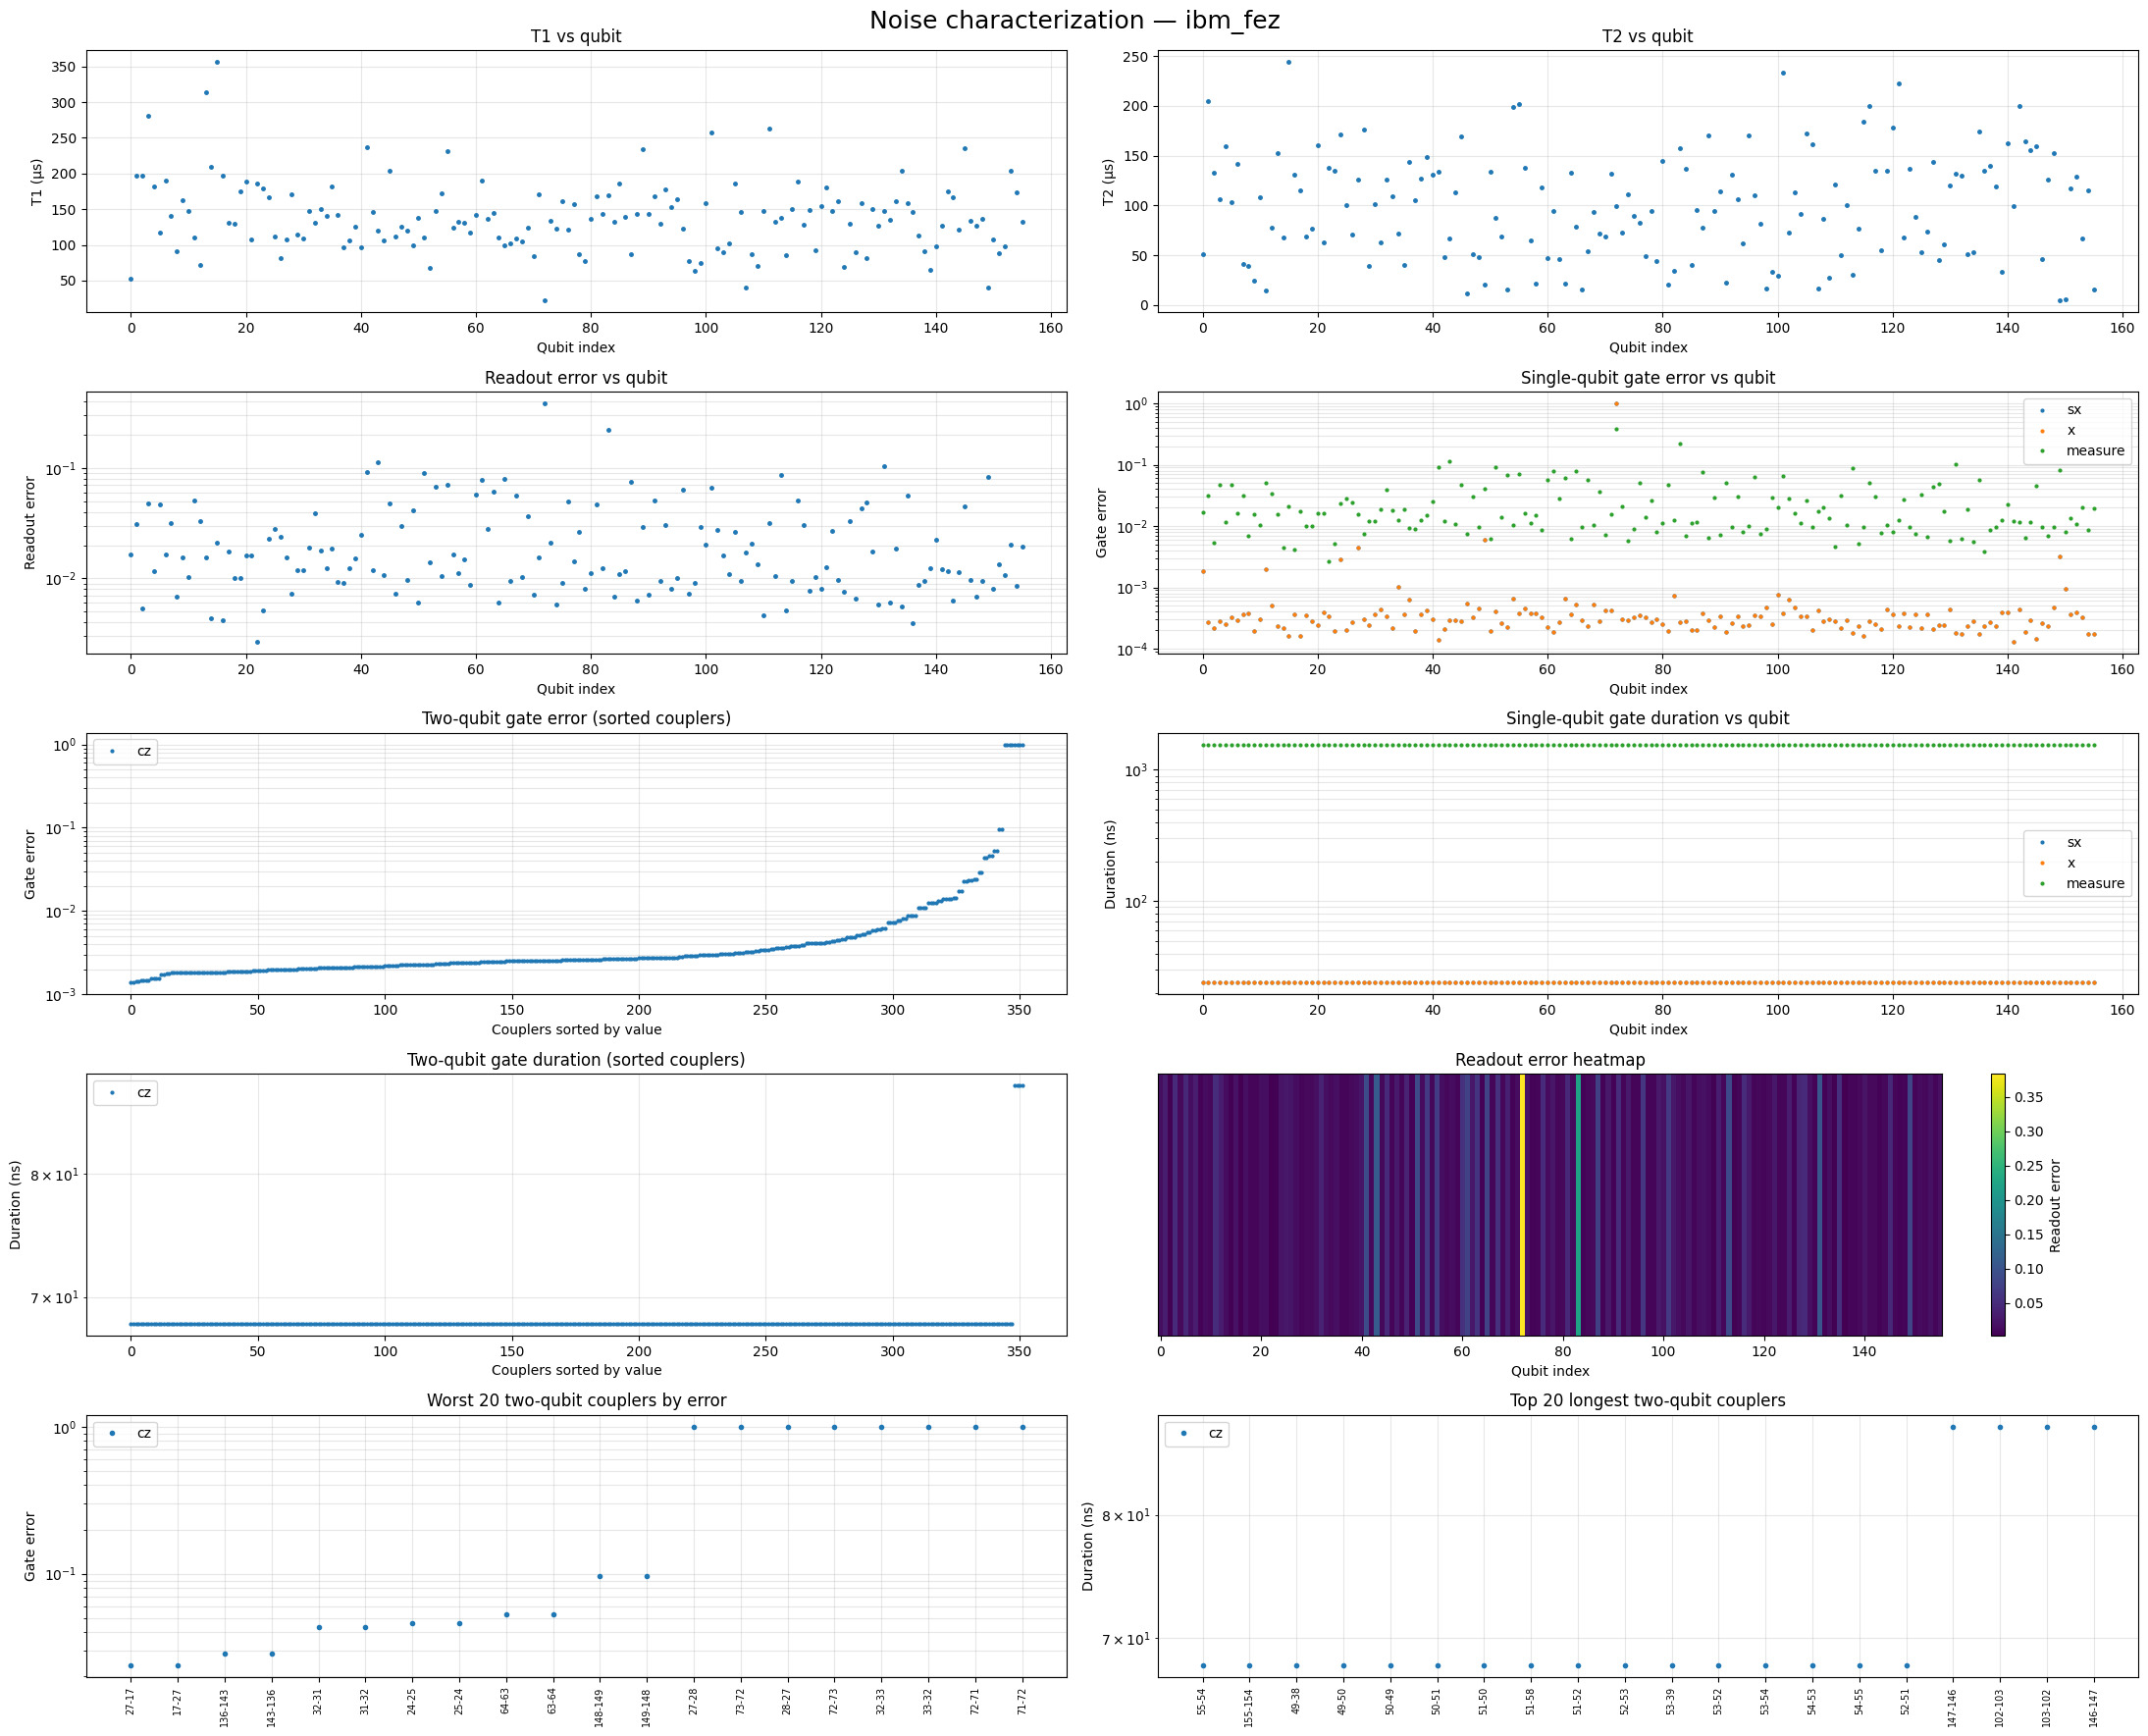

In [47]:
backend = service.backend("ibm_fez") # Choose avaiable processor
vis = BackendNoiseVisualizer(
    backend,
    gate_names=["rz", "sx", "x", "measure", "ecr", "cx", "cz"],
    figsize=(22, 18)
)

vis.print_summary()
print("\n \n ")
vis.plot_dashboard(top_k_couplers=20)

# 2 Two-level system driven by Circular Polarized Field

Given the following hamiltonian 
$$
H(t) = \frac{\omega_0}{2} Z + \Omega \left( X \cos(\omega t) + Y \sin(\omega t) \right)
$$

We can compute analytically the quasienergies
$$
\epsilon_{\pm} =
\frac{\omega}{2}
\pm
\sqrt{
\left(\frac{\omega}{2}-\frac{\omega_0}{2}\right)^2
+
\left(\frac{\Omega}{2}\right)^2
}
$$

The latter are defined $\mathrm{mod}\,\omega$, choosing 
$\epsilon_{\pm} \in \left[-\frac{\omega}{2},\,\frac{\omega}{2}\right]$, 
we see that 
$\epsilon_- = -\epsilon_+ \; (\mathrm{mod}\,\omega)$.

We define $h_1 := \frac{\omega _0}{2}, \; h_2:= \Omega$, while T is the period of the Hamiltonian

In all section 2 we choose $h_1 = 1, \; h_2 = \sqrt{2}, \; T = 1$

In [48]:
h1, h2, T = 1, np.sqrt(2), 1

## 2.1 Analytical distribution

Quasienergies computed analytically:


<IPython.core.display.Math object>

Period probability distribution: 10.923656334979848


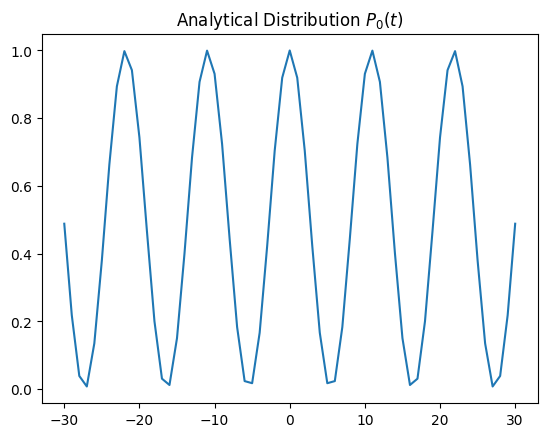

In [49]:
num_points = 60
# Probability distribution generated for t in [- num_points * T, num_points * T] with spacing dt = T

FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
epsilon = FS_noisless.quasi_energy_circular()

print("Quasienergies computed analytically:")
display(Math(r"\epsilon_{\pm} = \pm %.5f" % (epsilon)))
print(f"Period probability distribution: {2 * np.pi / epsilon}")

plt.title(f"Analytical Distribution $P_0(t)$")
t = T * np.arange(-int(num_points / 2), int(num_points / 2) + 1, 1)
P_analytical = (1 + np.cos(epsilon * t)) / 2
plt.plot(t, P_analytical)
plt.show()

### 2.1.1 Study of the reconstruction error with DFT and ANM

Given the analytical probability distribution
$$P_0(t)= \frac{1}{2} (1 + cos(\epsilon t))$$

with $\epsilon \approx 0.57519 $

We generate the analytical distribution in a given time window then use DFT and ANM to recover $\epsilon$.

For varying rent time windows we can compute the reconstruction error  


$$\frac{|\epsilon_{reconstructed} - \epsilon }{\epsilon}|$$

The goal is to identify the minimum time window for which DFT and ANM achieves a reconstruction with an error less than $10\%$.


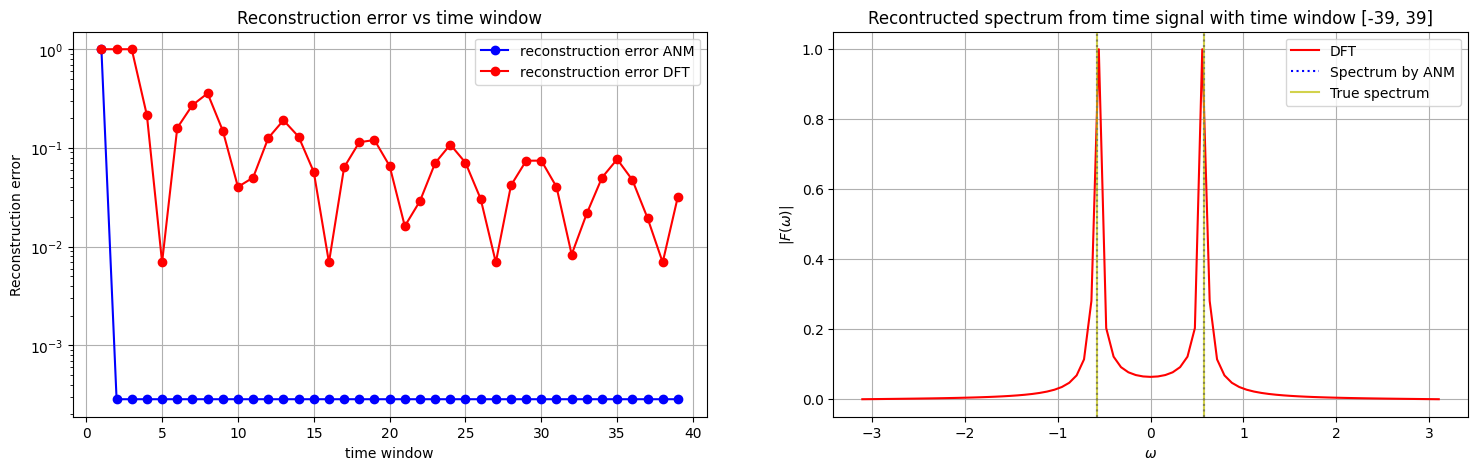

In [50]:
# Here reconstruction error is studied with time window varying from [-T, T] to [-T * max_time_window, T * max_time_window]
# In the plot on the left reconstruction error is showed vs time window, 
# while on the right spectrum reconstructed for that given time window

max_time_window = 40    # Max Time window to choose
step_size_time_window = 1 # Increment per loop

error_list_DFT = []
error_list_ANM = []
times = np.arange(1, max_time_window, step_size_time_window) * T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
for i, time_window in enumerate(times):
    t = np.arange(-time_window, time_window + step_size_time_window)
    P_analytical = (1 + np.cos(epsilon * t)) / 2
    DFT, ANM = Fourier_Transform(t, P_analytical - 1/2), Atomic_Norm_Minimization(t, P_analytical - 1/2)
    epsilon_ANM  = np.abs(ANM.get_spectrum(-np.pi, np.pi, lam=1e-5, plot=False, threshold=0.05, w_exp=[epsilon], num_nu=5000)[0])
    error_list_ANM.append(np.abs(epsilon - epsilon_ANM) / epsilon)
    result_DTF = DFT.get_DFT(plot=False)
    epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
    error_list_DFT.append(np.abs(epsilon - epsilon_DFT) / epsilon)


    ax1.clear()
    ax2.clear()

    ax1.plot(times[:i + 1], error_list_ANM, 'bo-', label="reconstruction error ANM")
    ax1.plot(times[:i + 1], error_list_DFT, 'ro-', label="reconstruction error DFT")
    ax1.set_yscale('log')
    ax1.set_xlabel("time window")
    ax1.set_ylabel("Reconstruction error")
    ax1.set_title("Reconstruction error vs time window")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(result_DTF[0], result_DTF[1], 'r', label="DFT")
    ax2.set_xlabel('$\omega$')
    ax2.set_ylabel('$|F(\omega)|$')
    ax2.set_title(f"Recontructed spectrum from time signal with time window [{-time_window}, {time_window}]")
    ax2.axvline(x=epsilon_ANM, color = 'b', ls = ":", label="Spectrum by ANM")
    ax2.axvline(x=-epsilon_ANM, color = 'b', ls = ":")
    ax2.axvline(x=epsilon, color = 'y', ls = "-", alpha=0.7, label="True spectrum")
    ax2.axvline(x=-epsilon, color = 'y', ls = "-", alpha=0.7)
    ax2.grid(True)
    ax2.legend()

    clear_output(wait=True)
    plt.pause(0.5)
    display(fig)

plt.close(fig)


We see that ANM achieves a good reconstruction error (0.02) with time window [-2, 2], going beyond the Fourier limit, as $2 < \frac{\pi}{\epsilon} \approx 5 $.

For [-3, 3] ANM converge towards an error of $3 \times 10^{-4}$.
DFT error decreased with an oscillatory behaviour and to oscillate around $10^{-4}$ it needs a time window of about 2000.(See next cell)

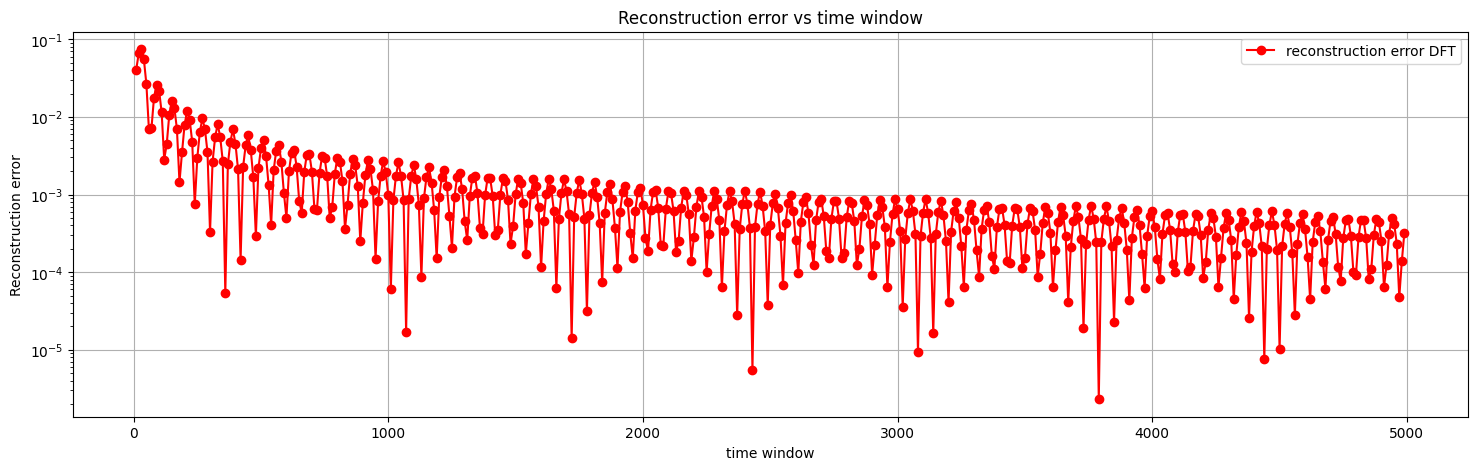

In [51]:
# Static plot Reconstruction error vs time window for DFT

max_time_window = 5000    # Max Time window (in periods T) to choose
step_size_time_window = 10  # Increment (in periods T) per loop

error_list_DFT = []
times = np.arange(step_size_time_window, min(max_time_window, max_time_window + step_size_time_window), step_size_time_window) * T

fig, ax1 = plt.subplots(figsize=(18, 5))
for i, time_window in enumerate(times):
    t = np.arange(-time_window, time_window + 1)
    P_analytical = (1 + np.cos(epsilon * t)) / 2
    DFT, ANM = Fourier_Transform(t, P_analytical - 1/2), Atomic_Norm_Minimization(t, P_analytical)
    result_DTF = DFT.get_DFT(plot=False)
    epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
    error_list_DFT.append(np.abs(epsilon - epsilon_DFT) / epsilon)


    ax1.clear()

    ax1.plot(times[:i + 1], error_list_DFT, 'ro-', label="reconstruction error DFT")
    ax1.set_yscale('log')
    ax1.set_xlabel("time window")
    ax1.set_ylabel("Reconstruction error")
    ax1.set_title("Reconstruction error vs time window")
    ax1.legend()
    ax1.grid(True)

    clear_output(wait=True)
    display(fig)

plt.close(fig)


In conclusion the minimum time window to achieve an error less than $10\%$  for ANM is $[-2, 2]$ with error 0.002 

while for DFT is $[-5, 5]$ with error $0.006$

## 2.2 Trotter Error Analysis (No quantum noise)

### 2.2.1 Relative MAE Error

We study the relative MAE error between the probability obtained from quantum simlation with Trotter formulas and the analytical one,
for t = 2 and t = 5 as they correspond to the maximum time we will need to simulate for achieving a good recovery with ANM and DFT.

In [52]:
FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
simulator = AerSimulator()


def get_MAE_Trotter_error(t, Order_formula, num_Trotter_steps, shots=10 ** 6):
    U = FS_noisless.evolution_operator(t_f=t, t_0=0, Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, Polarization="Circular")
    qc = FS_noisless.SWAP_test(coeff=[1, 0], U=U)
    qc = transpile(qc, backend=simulator)
    job = simulator.run(qc, shots=shots)
    Prob = job.result().get_counts().get('0', 0) / shots
    P_analytical = (1 + np.cos(t * FS_noisless.quasi_energy_circular())) / 2
    return abs(Prob - P_analytical) / P_analytical

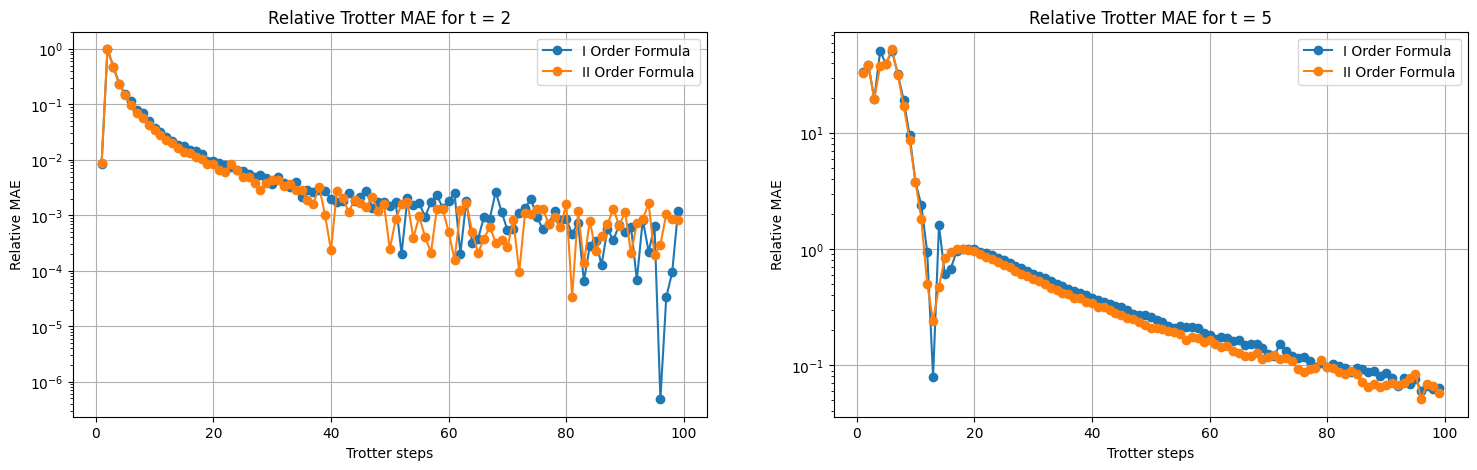

In [53]:
# Error studied in range [delta_num_Trotter_steps, Max_num_Trotter_steps] with increments of delta_num_Trotter_steps
FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])

Max_num_Trotter_steps = 100       
delta_num_Trotter_steps = 1

array_num_Trotter_steps = np.arange(delta_num_Trotter_steps, Max_num_Trotter_steps, delta_num_Trotter_steps)
t_2_MAE_error_list = [[], []]
t_5_MAE_error_list = [[], []]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
for i, num_Trotter_steps in enumerate(array_num_Trotter_steps):
    t_2_MAE_error_list[0].append(get_MAE_Trotter_error(t=2, Order_formula="First", num_Trotter_steps=num_Trotter_steps))
    t_2_MAE_error_list[1].append(get_MAE_Trotter_error(t=2, Order_formula="Second", num_Trotter_steps=num_Trotter_steps))
    t_5_MAE_error_list[0].append(get_MAE_Trotter_error(t=5, Order_formula="First", num_Trotter_steps=num_Trotter_steps))
    t_5_MAE_error_list[1].append(get_MAE_Trotter_error(t=5, Order_formula="Second", num_Trotter_steps=num_Trotter_steps))

    ax1.clear()
    ax2.clear()

    ax1.set_title(f"Relative Trotter MAE for t = 2")
    ax1.plot(array_num_Trotter_steps[:i + 1], t_2_MAE_error_list[0], '-o', label='I Order Formula')
    ax1.plot(array_num_Trotter_steps[:i + 1], t_2_MAE_error_list[1], '-o', label='II Order Formula')
    ax1.set_yscale('log')
    ax1.set_xlabel("Trotter steps")
    ax1.set_ylabel("Relative MAE")
    ax1.grid(True)
    ax1.legend()

    ax2.set_title(f"Relative Trotter MAE for t = 5")
    ax2.plot(array_num_Trotter_steps[:i + 1], t_5_MAE_error_list[0], '-o', label='I Order Formula')
    ax2.plot(array_num_Trotter_steps[:i + 1], t_5_MAE_error_list[1], '-o', label='II Order Formula')
    ax2.set_yscale('log')
    ax2.set_xlabel("Trotter steps")
    ax2.set_ylabel("Relative MAE")
    ax2.grid(True)
    ax2.legend()

    clear_output(wait=True)
    display(fig)

plt.close(fig)

We see that for t=2 ) the relative error converges to less than $10\%$ for 7 Trotter steps and I Order Formula and for 6 Trotter steps and II Order fromula.

While for t = 5 (DFT), the relative error converges to less than $10\%$ for 83 Trotter steps and I Order Formula and for 86 Trotter steps and II

### 2.2.2 Probability distribution obtained with Trotter formulas

Here we show on the left the probability distribution for a range of Trotter steps and on the right the reconstruction error as a function of time.

We treated both the time windows [-2, 2] and [-5, 5]

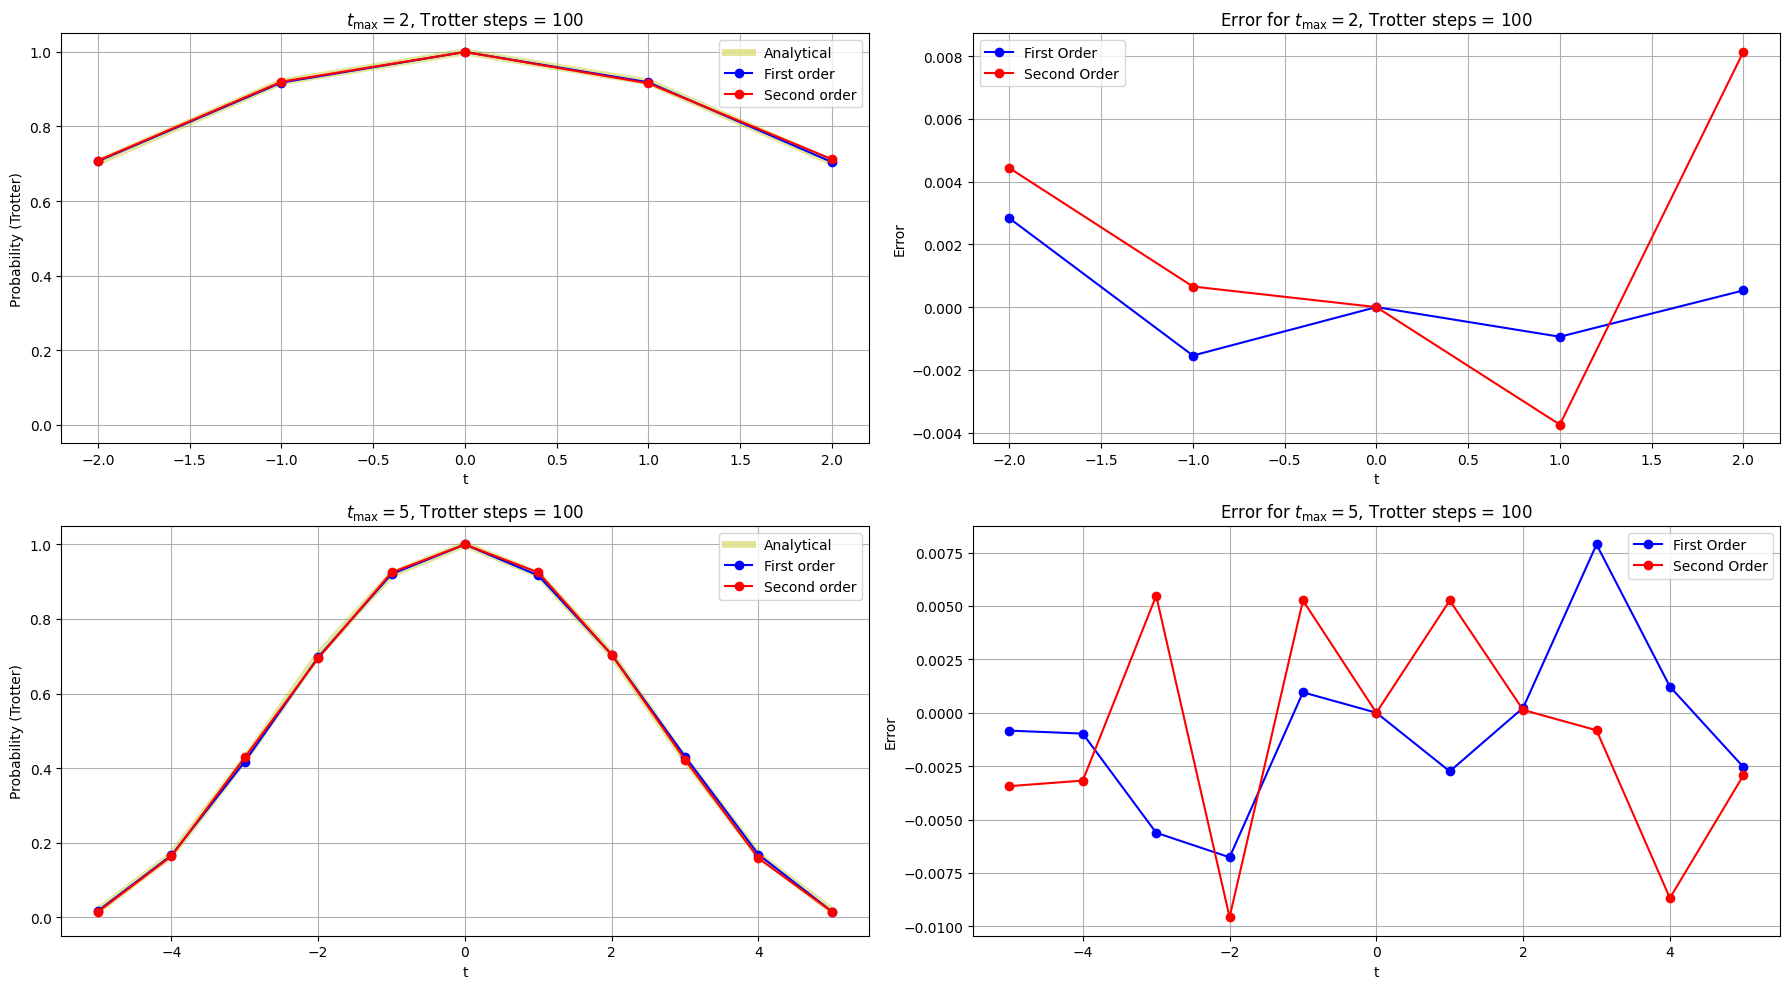

In [54]:
# Live plot :Probability distribution in function of time for different number of Trotter steps, in range [delta_num_Trotter_steps, Max_num_Trotter_steps]
# with increments of delta_num_Trotter_steps

FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
epsilon = FS_noisless.quasi_energy_circular()

Max_num_Trotter_steps = 101
delta_num_Trotter_steps = 1

array_num_Trotter_steps = np.arange(delta_num_Trotter_steps, Max_num_Trotter_steps, delta_num_Trotter_steps)

t_max_values = [2, 5]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
display_handle = display(fig, display_id=True)

for num_Trotter_steps in array_num_Trotter_steps:
    for ax in axes.flatten():
        ax.clear()

    for row, t_max in enumerate(t_max_values):

        fname_first = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=First_t_MAX={t_max}_Trotter_steps={num_Trotter_steps}.txt"
        if not os.path.exists(fname_first):
            FS_noisless.get_distribution0(Order_formula="First", num_Trotter_steps=num_Trotter_steps, num_points=2 * int(t_max / T))
        t_first, P_first = np.loadtxt(fname_first, unpack=True)

        fname_second = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=Second_t_MAX={t_max}_Trotter_steps={num_Trotter_steps}.txt"
        if not os.path.exists(fname_second):
            FS_noisless.get_distribution0(Order_formula="Second", num_Trotter_steps=num_Trotter_steps, num_points=2 * int(t_max / T))
        t_second, P_second = np.loadtxt(fname_second, unpack=True)

        P_analytical = (1 + np.cos(epsilon * t_first)) / 2
        error_first = P_first - P_analytical
        error_second = P_second - P_analytical

        # probability distributions
        ax_prob = axes[row, 0]
        ax_prob.plot(t_first, P_analytical, color='y', alpha=0.4, linewidth=5, label="Analytical")
        ax_prob.plot(t_first, P_first, 'bo-', label="First order")
        ax_prob.plot(t_second, P_second, 'ro-', label="Second order")

        ax_prob.set_xlabel("t")
        ax_prob.set_ylabel("Probability (Trotter)")
        ax_prob.set_title(
            rf"$t_{{\max}}={t_max}$, Trotter steps = {num_Trotter_steps}"
        )
        ax_prob.set_ylim(-0.05, 1.05)
        ax_prob.grid(True)
        ax_prob.legend()

        # errors
        ax_err = axes[row, 1]
        ax_err.plot(t_first, error_first, 'bo-', label="First Order")
        ax_err.plot(t_second, error_second, 'ro-', label="Second Order")

        ax_err.set_xlabel("t")
        ax_err.set_ylabel("Error")
        ax_err.set_title(
            rf"Error for $t_{{\max}}={t_max}$, Trotter steps = {num_Trotter_steps}"
        )
        ax_err.grid(True)
        ax_err.legend()

    fig.tight_layout()
    clear_output(wait=True)
    display(fig)
    plt.pause(0.5)

plt.close(fig)


### 2.2.3 Study the Reconstruction error DFT and ANM with Trotter Error

We repeat the analasys done in paragraph 2.1.1, but this time we extract the quasienergies from the probability distribution obtained by Quantum Simulation with Trotter Formulas and

fix the time window (t=2 for ANM and t=5 for DFT), but vary the number of Trotter steps.

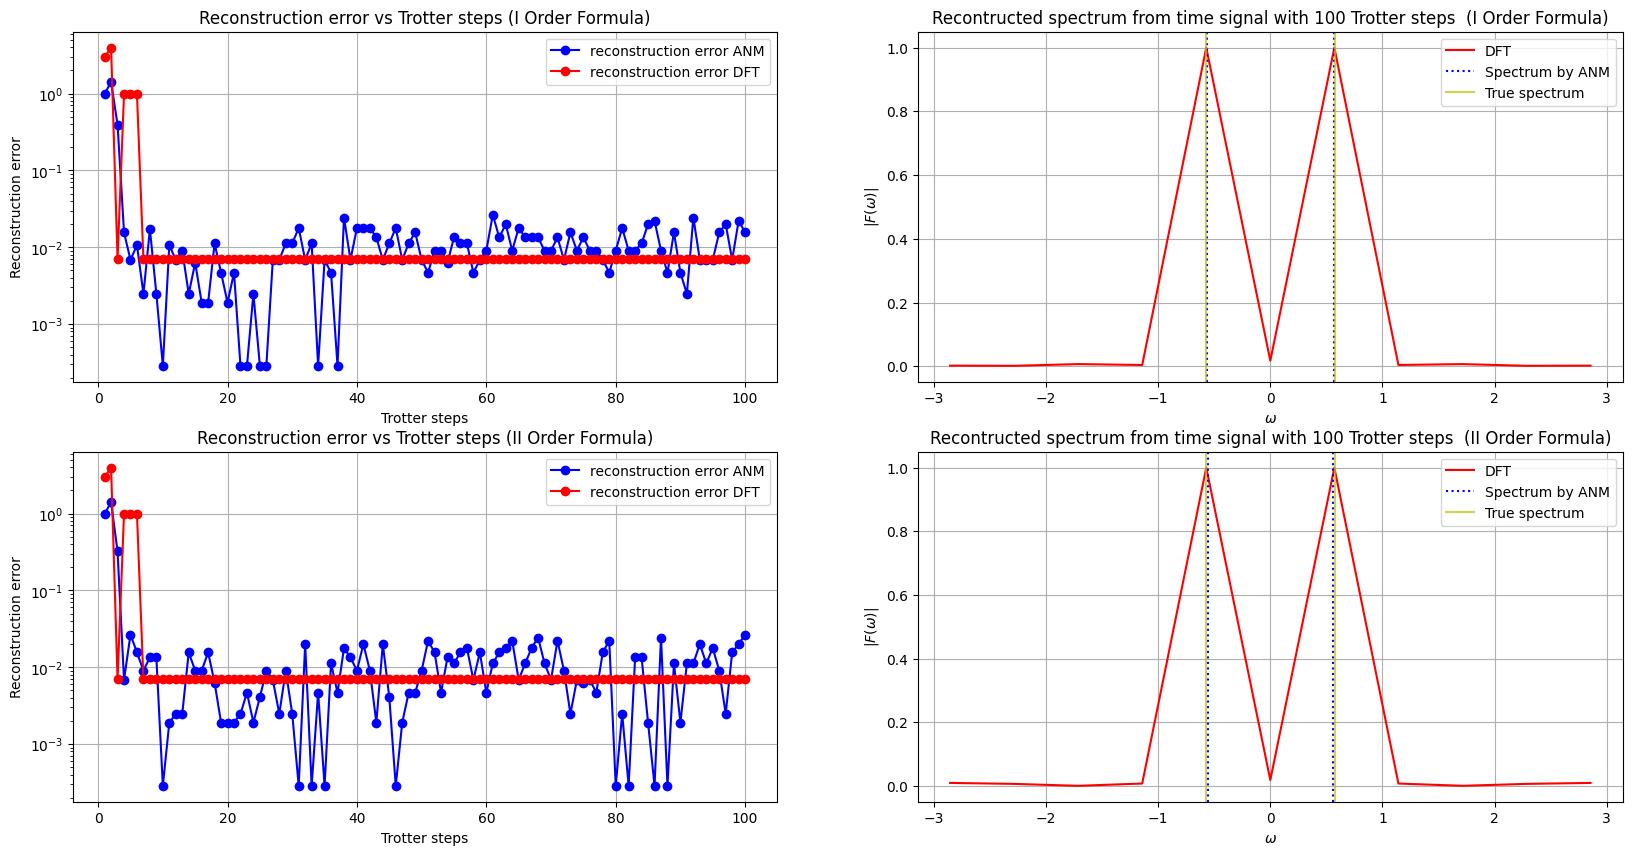

In [55]:
# Live plot: On the left Reconstruction error studied vs Trotter steps in range [delta_num_Trotter_steps, Max_num_Trotter_steps] with increments of delta_num_Trotter_steps
# On the right spectrum reconstructed with DFT and ANM using signal obtained with Trotter steps in range [delta_num_Trotter_steps, Max_num_Trotter_steps]
Max_num_Trotter_steps = 101       
delta_num_Trotter_steps = 1


array_num_Trotter_steps = np.arange(delta_num_Trotter_steps, Max_num_Trotter_steps, delta_num_Trotter_steps)
num_points_t_2 = 5
num_points_t_5 = 11
error_list_DFT_Trotter = [[], []]
error_list_ANM_Trotter = [[], []]

FS_noisless = FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
epsilon = FS_noisless.quasi_energy_circular()


fig, axes = plt.subplots(2, 2, figsize=(20, 10))
for i, num_Trotter_steps in enumerate(array_num_Trotter_steps):
    [ax.clear() for ax in axes.flatten()]
    for j, Order_formula in enumerate(["First", "Second"]):
        fname_t_2 = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order={Order_formula}_t_MAX=2_Trotter_steps={num_Trotter_steps}.txt"
        fname_t_5 = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order={Order_formula}_t_MAX=5_Trotter_steps={num_Trotter_steps}.txt"
        if not os.path.exists(fname_t_2):
            FS_noisless.get_distribution0(Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, num_points=num_points_t_2)
        time_t_2, P_t_2 = np.loadtxt(fname_t_2, unpack=True)
        if not os.path.exists(fname_t_5):
            FS_noisless.get_distribution0(Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, num_points=num_points_t_5)
        time_t_5, P_t_5 = np.loadtxt(fname_t_5, unpack=True)

        DFT, ANM = Fourier_Transform(time_t_5, P_t_5 - 1/2), Atomic_Norm_Minimization(time_t_2, P_t_2 - 1/2)
        lam = max(4 * 2.25 / (num_Trotter_steps ** 2), 0.02)   #0.025
        epsilon_ANM  = np.abs(ANM.get_spectrum(-np.pi, np.pi, lam=lam, plot=False, threshold=0.05, w_exp=[epsilon], num_nu=5000)[0])
        error_list_ANM_Trotter[j].append(np.abs(epsilon - epsilon_ANM) / epsilon)
        result_DTF = DFT.get_DFT(plot=False)
        epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
        error_list_DFT_Trotter[j].append(np.abs(epsilon - epsilon_DFT) / epsilon)

 

        ax1 = axes[:,0]
        ax1[j].plot(array_num_Trotter_steps[:i + 1], error_list_ANM_Trotter[j], 'bo-', label="reconstruction error ANM")
        ax1[j].plot(array_num_Trotter_steps[:i + 1], error_list_DFT_Trotter[j], 'ro-', label="reconstruction error DFT")
        ax1[j].set_yscale('log')
        ax1[j].set_xlabel("Trotter steps")
        ax1[j].set_ylabel("Reconstruction error")
        ax1[j].set_title(f"Reconstruction error vs Trotter steps ({'I' * (j + 1)} Order Formula)")
        ax1[j].legend()
        ax1[j].grid(True)

        ax2 = axes[:,1]
        ax2[j].plot(result_DTF[0], result_DTF[1], 'r', label="DFT")
        ax2[j].set_xlabel(r'$\omega$')
        ax2[j].set_ylabel(r'$|F(\omega)|$')
        ax2[j].set_title(f"Recontructed spectrum from time signal with {num_Trotter_steps} Trotter steps  ({'I' * (j + 1)} Order Formula)")
        ax2[j].axvline(x=epsilon_ANM, color = 'b', ls = ":", label="Spectrum by ANM")
        ax2[j].axvline(x=-epsilon_ANM, color = 'b', ls = ":")
        ax2[j].axvline(x=epsilon, color = 'y', ls = "-", alpha=0.7, label="True spectrum")
        ax2[j].axvline(x=-epsilon, color = 'y', ls = "-", alpha=0.7)
        ax2[j].grid(True)
        ax2[j].legend()

    clear_output(wait=True)
    plt.pause(0.5)
    display(fig)
    [ax.clear() for ax in axes.flatten()]

plt.close(fig)

For the choice of the hyperparameter we recall that for Gaussian noise with std 
$\sigma$

$\lambda \sim \sigma \sqrt{n \log n}$
with $n$ being the size of the signal

The error is characterized by two regimes:
one in which Trotter error is dominant and the second where statistical noise is dominant, with relative fluctuations of $10^{-2}$ (having choosen $10^{-4}$ shots).

For the first regime, we use an approximate model, noticing that Trotter error decreases quadratically with Trotter steps for both formulas(see paragraph 2.2.1)
starting from 2 Trotter steps where relative MAE is 1 for t = 2.
Clearly this is an upper bound, as the error is maximum towards the maximum time window.

In the statistical regime, the $\sigma < 0.01 $.

Putting the two results together, after some tuning we have found that a suitable choice of 
$\lambda$

$$ \lambda(N_{\text{TrotterSteps}}) = \max (\frac{9}{N_{\text{TrotterSteps}}^2}, 0.02 ) $$


We see that after seven Trotter steps DFT error converges to 0.007, while ANM error oscillates around it and with a proper choice of $\lambda$ can go below 0.001.
However, if the goal is to use the minimum number of Trotter steps to recover the quasienergies with an error smaller than $10 \% $ then for this Hamiltonian in absence of quantum noise ANM does not provide an advantage.
In fact DFT with 3 Trotter steps achieve an error of 0.007, while ANM about 0.01 even tuning the hyperparameter $\lambda$ as we show in next cell.

However if we want to recover the quasienergies with the highest precision ANM results advantageous as reconstruction error can go below than 0.001 with appropriate choice of Trotter steps(10 and II Order formula) and the hyperparameter $\lambda$.

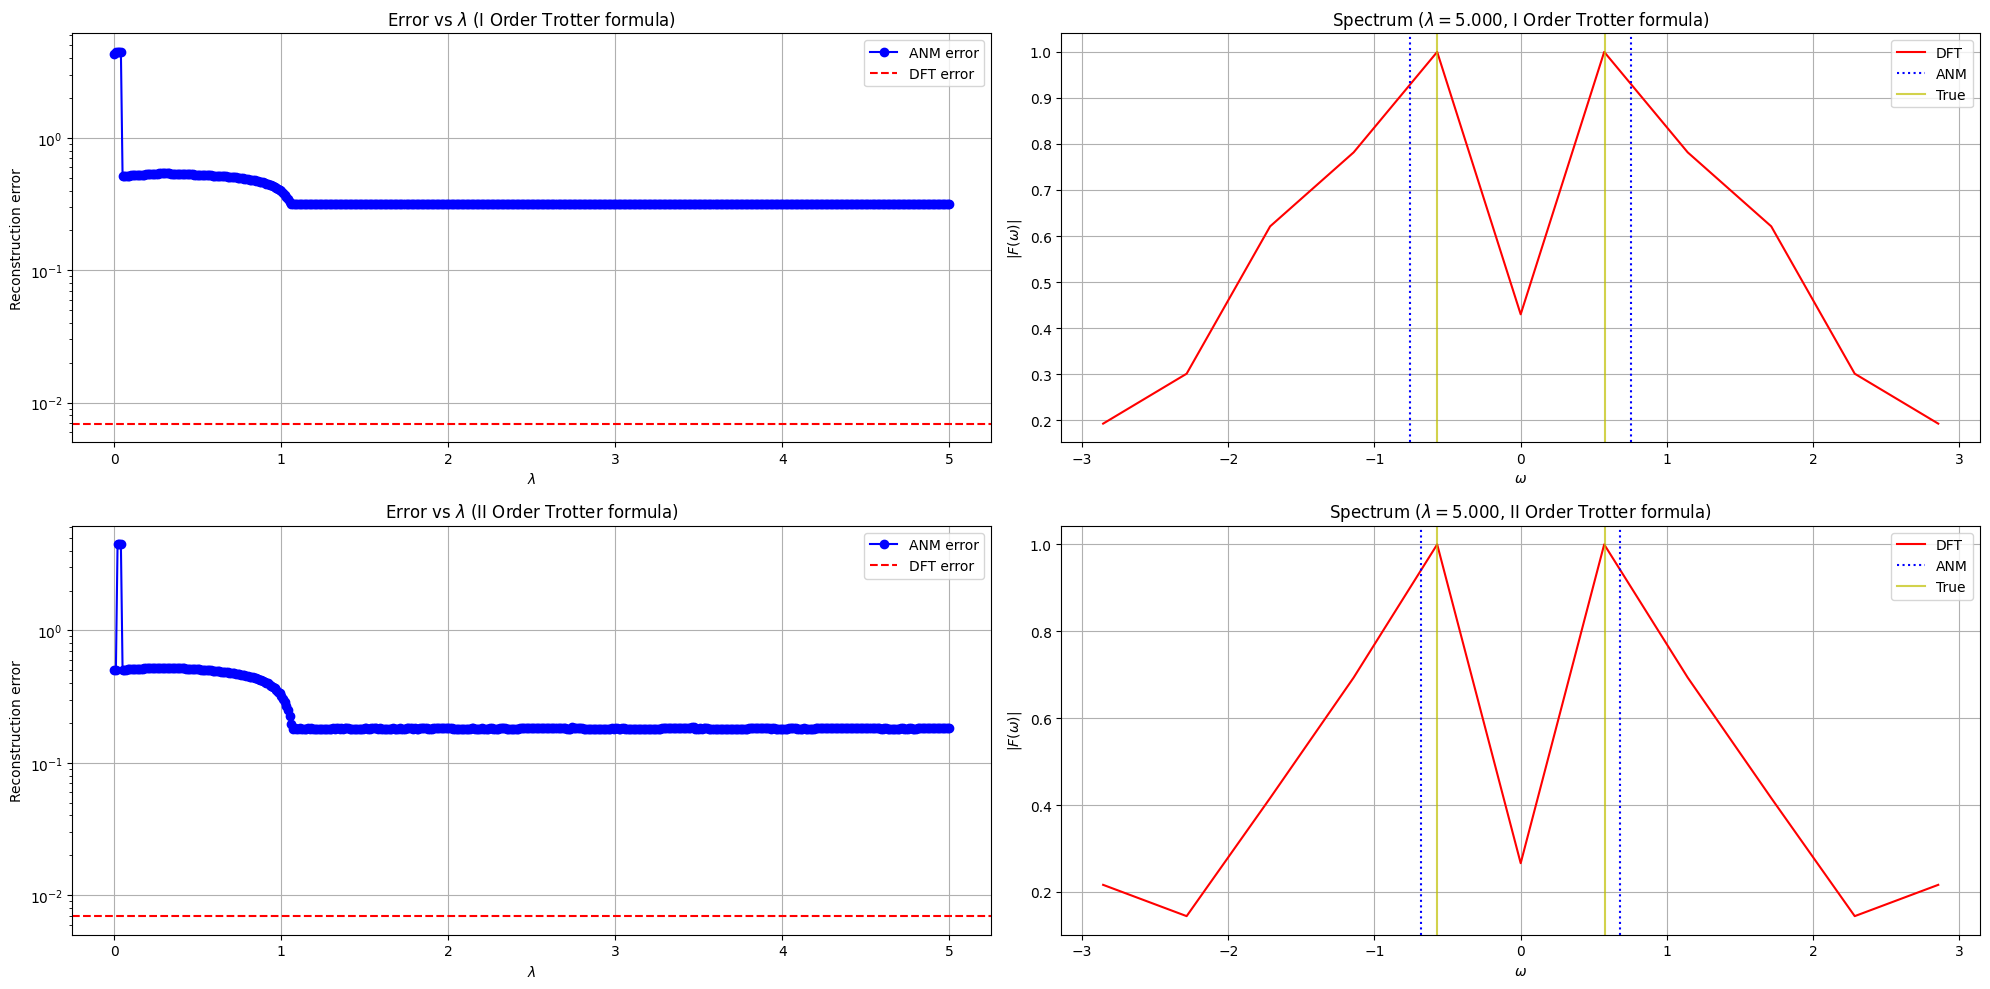

In [56]:
# Here we show that even with appropriate tuning of lambda for 3 Trotter steps we cannot go below a recxonstruction error of 0.1.
# Live plot: On the left reconstruction error versus lambda 
# On the right spectrum reconstructed for varying lambda
num_Trotter_steps = 3
lam_values = np.linspace(0., 5, 501)

FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
epsilon = FS_noisless.quasi_energy_circular()

error_list_ANM = [[], []]

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

fname_t_2_first = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=First_t_MAX=2_Trotter_steps={num_Trotter_steps}.txt"
fname_t_2_second = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=Second_t_MAX=2_Trotter_steps={num_Trotter_steps}.txt"
fname_t_5_first = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=First_t_MAX=5_Trotter_steps={num_Trotter_steps}.txt"
fname_t_5_second = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=Second_t_MAX=5_Trotter_steps={num_Trotter_steps}.txt"

time_t_2_first, P_t_2_first = np.loadtxt(fname_t_2_first, unpack=True)
time_t_2_second, P_t_2_second = np.loadtxt(fname_t_2_second, unpack=True)
time_t_5_first, P_t_5_first = np.loadtxt(fname_t_5_first, unpack=True)
time_t_5_second, P_t_5_second = np.loadtxt(fname_t_5_second, unpack=True)

DFT_first = Fourier_Transform(time_t_5_first, P_t_5_first - 1/2)
result_DFT_first = DFT_first.get_DFT(plot=False)
epsilon_DFT_first = np.abs(result_DFT_first[0][np.argmax(result_DFT_first[1])])
error_DFT_first = np.abs(epsilon - epsilon_DFT_first) / epsilon

DFT_second = Fourier_Transform(time_t_5_second, P_t_5_second - 1/2)
result_DFT_second = DFT_second.get_DFT(plot=False)
epsilon_DFT_second = np.abs(result_DFT_second[0][np.argmax(result_DFT_second[1])])
error_DFT_second = np.abs(epsilon - epsilon_DFT_second) / epsilon

error_DFT = [error_DFT_first, error_DFT_second]
result_DFT_all = [result_DFT_first, result_DFT_second]

for i, lam in enumerate(lam_values):
    for ax in axes.flatten():
        ax.clear()

    for j, Order_formula in enumerate(["First", "Second"]):
        if Order_formula == "First":
            ANM = Atomic_Norm_Minimization(time_t_2_first, P_t_2_first - 1/2)
            result_DFT = result_DFT_all[0]
        else:
            ANM = Atomic_Norm_Minimization(time_t_2_second, P_t_2_second - 1/2)
            result_DFT = result_DFT_all[1]

        epsilon_ANM = np.abs(ANM.get_spectrum(-np.pi, np.pi, lam=lam, plot=False, threshold=0.05, w_exp=[epsilon], num_nu=5000)[0])
        error_list_ANM[j].append(np.abs(epsilon - epsilon_ANM) / epsilon)

        ax_left = axes[j, 0]
        ax_left.plot(lam_values[:i + 1], error_list_ANM[j], 'bo-', label="ANM error")
        ax_left.axhline(y=error_DFT[j], color='r', ls='--', label="DFT error")
        ax_left.set_yscale('log')
        ax_left.set_xlabel(r'$\lambda$')
        ax_left.set_ylabel("Reconstruction error")
        ax_left.set_title(f"Error vs $\\lambda$ ({'I' * (j + 1)} Order Trotter formula)")
        ax_left.grid(True)
        ax_left.legend()

        ax_right = axes[j, 1]
        ax_right.plot(result_DFT[0], result_DFT[1], 'r', label="DFT")
        ax_right.axvline(x=epsilon_ANM, color='b', ls=':', label="ANM")
        ax_right.axvline(x=-epsilon_ANM, color='b', ls=':')
        ax_right.axvline(x=epsilon, color='y', ls='-', alpha=0.7, label="True")
        ax_right.axvline(x=-epsilon, color='y', ls='-', alpha=0.7)
        ax_right.set_xlabel(r'$\omega$')
        ax_right.set_ylabel(r'$|F(\omega)|$')
        ax_right.set_title(rf"Spectrum ($\lambda={lam:.3f}$, {'I' * (j + 1)} Order Trotter formula)")
        ax_right.grid(True)
        ax_right.legend()

    plt.tight_layout()
    clear_output(wait=True)
    display(fig)

plt.close(fig)

We see that ANM reconstruction error for time window 2 and 3 Trotter steps, II Order Formula, converges towards 0.2, 

while DFT using a time window 5 and same Trotter steps goes below 0.01.

## 2.3 Error analysis with quantum noise

As discussed in Section 1, the native gate set available on the considered backends consists of $R_x$, $R_z$, $X$, $S_x$, and $CZ$. Therefore, any circuit must be decomposed into this set of gates.

This decomposition is handled by Qiskit through its transpilation process, which offers different optimization levels. These optimizations aim to reduce the total number of gates and circuit depth, while also taking into account hardware constraints such as qubit connectivity, particularly important for $C_U$ gates.

Upon revisiting the code developed during my thesis work, I realized that the circuits were not optimized at all. As a result, they exhibited unnecessarily large depths even for a small number of Trotter steps. This prevent me from extracting meaningful results, even for relatively simple Hamiltonians.

For this reason, I slightly revise the approach discussed in our last meeting. I will first focus on minimizing the circuit depth using Qiskit’s transpilation algorithms, and then repeat the Trotter error analysis presented in Section 2.2, this time on a noisy simulator which mateches quantum noise of an avaiable backend.


### 2.3.1 Mapping circuit on hardware

Qiskit offer from optimization levels from 0 (basic traslation, no optimization) to 3 (high optimization).

We start by seeing how our modified SWAP test varies with 1 Trotter step vary with different optimization levels

Circuit with Optimization level = 0

=== Circuit Gate Summary ===
   RZ : 75
   SX : 34
   CZ : 10


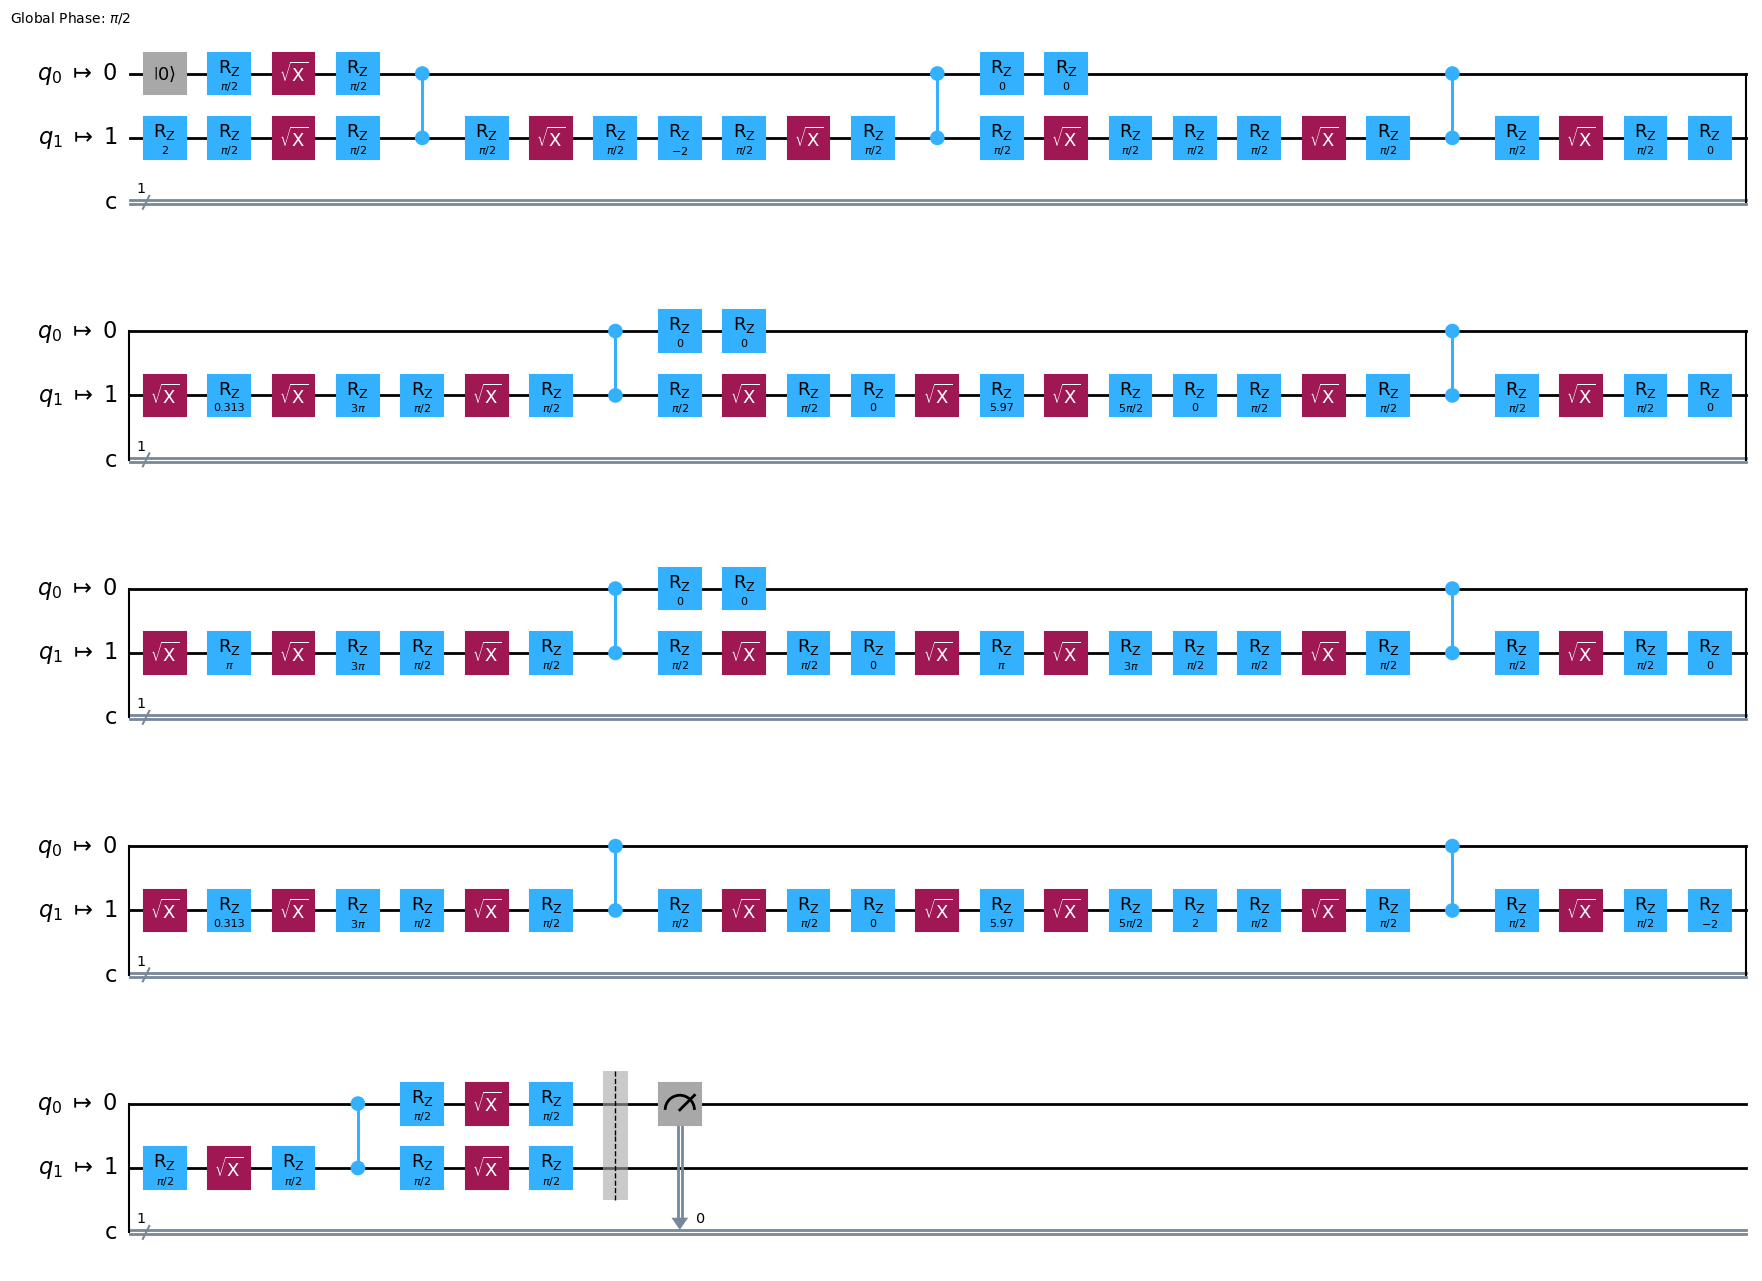

Circuit with Optimization level = 1

=== Circuit Gate Summary ===
   RZ : 23
   SX : 17
   CZ : 8


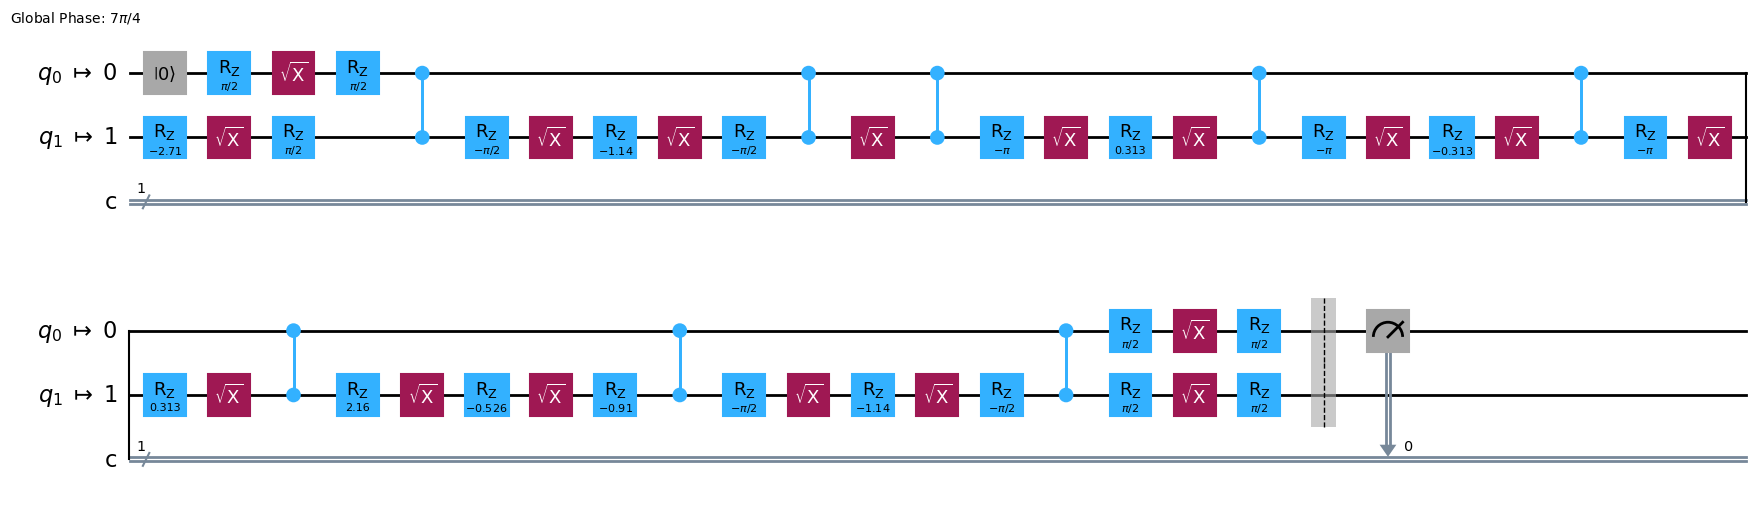

Circuit with Optimization level = 2

=== Circuit Gate Summary ===
   SX : 10
   RZ : 9
   CZ : 2
    X : 1


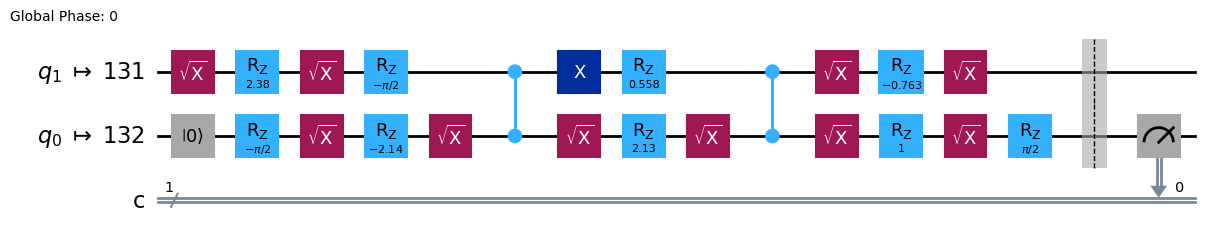

Circuit with Optimization level = 3

=== Circuit Gate Summary ===
   SX : 10
   RZ : 9
   CZ : 2
    X : 1


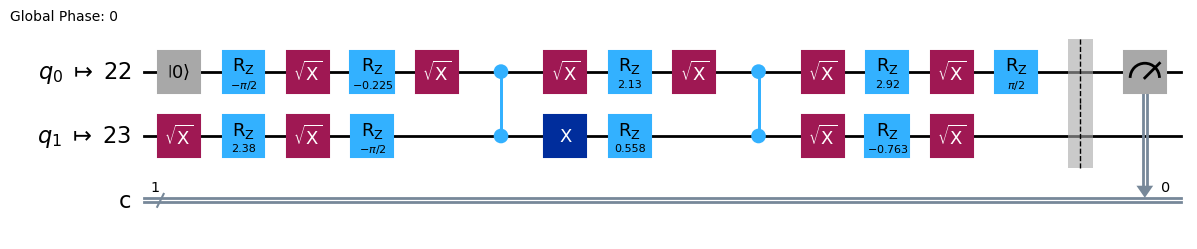

In [57]:
FS = Floquet_Simulation(T=T, parameters=[h1, h2])
U = FS.evolution_operator(t_f=2, t_0=-2, num_Trotter_steps=1, Polarization="Circular", Order_formula="Second")
qc = QuantumCircuit(2, 1)
qc.append(FS.SWAP_test(coeff=[1, 0], U=U), [0, 1], [0])

for optimization_level in range(0, 4):
    print(f"Circuit with Optimization level = {optimization_level}")
    tqc = transpile(qc, backend=backend, optimization_level=optimization_level)
    show_circuit(tqc, verbose=True, draw=True)

Now we see how the number of gates varies in function of the optimization level for time window [-2,2] and subsequent cell for [-5, 5]

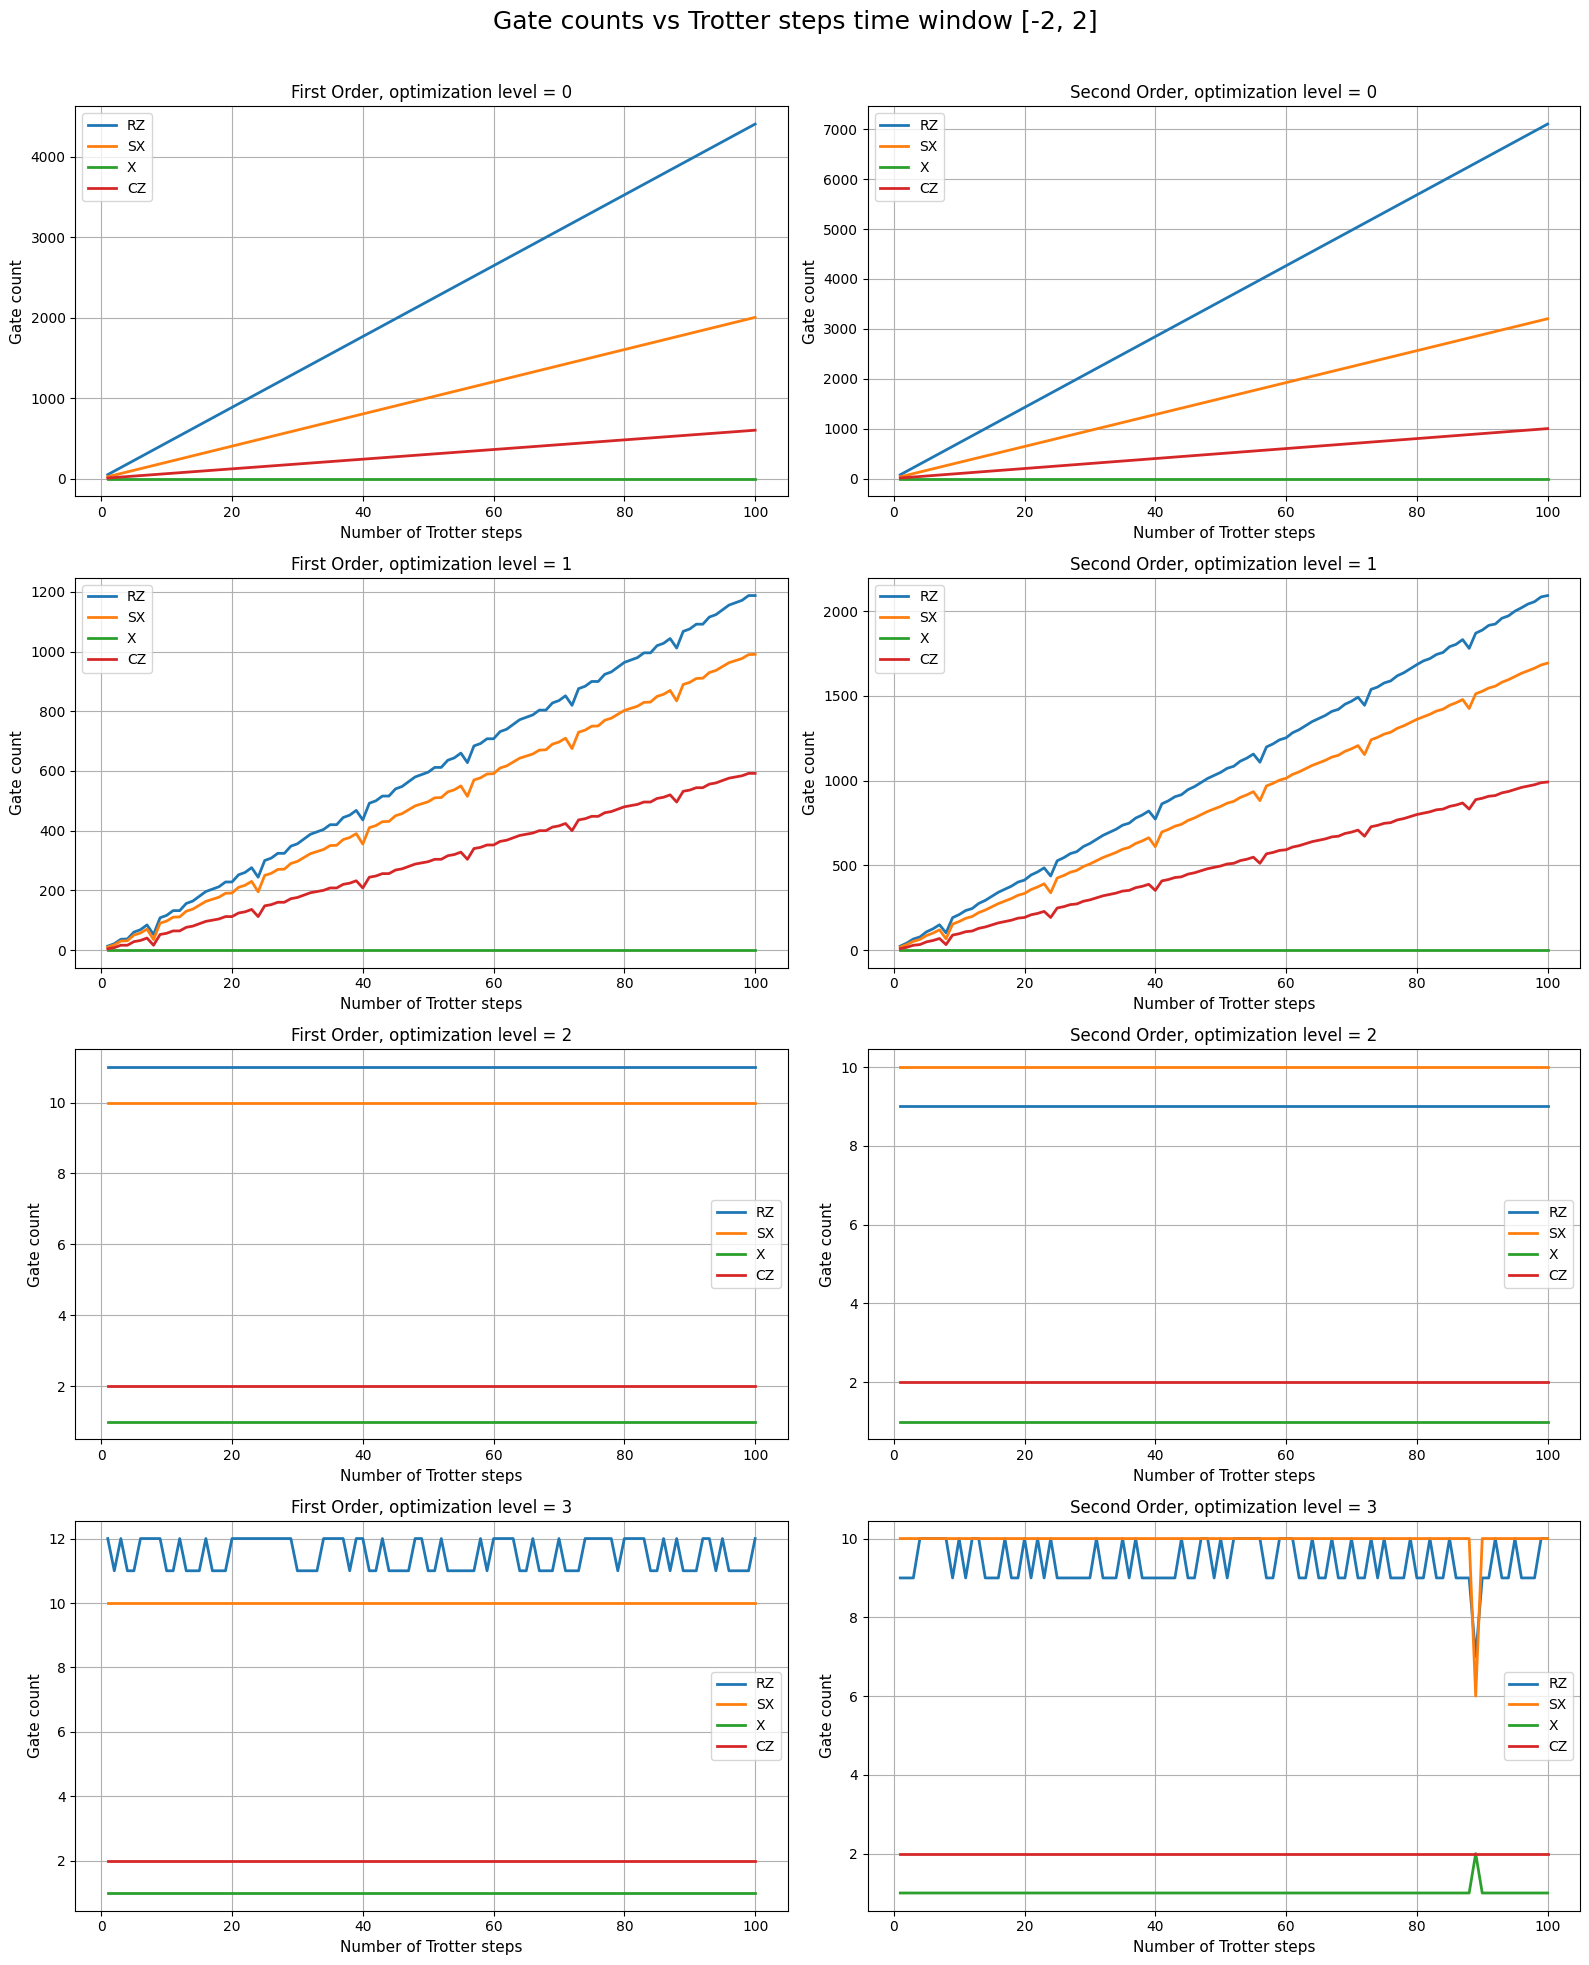

In [58]:
max_num_trotter_steps = 100
array_num_trotter_steps = np.arange(1, max_num_trotter_steps + 1)

optimization_levels = [0, 1, 2, 3]
orders = ["First", "Second"]
gates_to_track = ["rz", "sx", "x", "cz"]

gate_counts = {
    order: {
        optimization_level: {gate: [] for gate in gates_to_track}
        for optimization_level in optimization_levels
    }
    for order in orders
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=True)
display_handle = display(fig, display_id=True)

for num_trotter_steps in array_num_trotter_steps:

    for ax in axes.flatten():
        ax.clear()

    for order in orders:
        U = FS.evolution_operator(t_f=2, t_0=-2, num_Trotter_steps=num_trotter_steps, Polarization="Circular", Order_formula=order)

        qc = QuantumCircuit(2, 1)
        qc.append(FS.SWAP_test(coeff=[1, 0], U=U), [0, 1], [0])

        for optimization_level in optimization_levels:
            tqc = transpile(qc, backend=backend, optimization_level=optimization_level)
            dict_gates = tqc.count_ops()

            for gate in gates_to_track:
                gate_counts[order][optimization_level][gate].append(dict_gates.get(gate, 0))

    for row, optimization_level in enumerate(optimization_levels):
        for col, order in enumerate(orders):
            ax = axes[row, col]

            for gate in gates_to_track:
                ax.plot(array_num_trotter_steps[:len(gate_counts[order][optimization_level][gate])], gate_counts[order][optimization_level][gate], label=gate.upper(), linewidth=2)

            ax.set_title(f"{order} Order, optimization level = {optimization_level}", fontsize=12)
            ax.set_ylabel("Gate count", fontsize=11)
            ax.set_xlabel("Number of Trotter steps", fontsize=11)
            ax.tick_params(axis="x", labelbottom=True)
            ax.set_xticks(np.arange(0, max_num_trotter_steps + 1, 20))

            ax.grid(True)
            ax.legend()

    fig.suptitle("Gate counts vs Trotter steps time window [-2, 2]", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    clear_output(wait=True)
    display(fig)

plt.close(fig)

We see that when optimization level $\geq$ 2 the depth of the circuit depth stops growing with the number of Trotter steps,
then for next section we set optimization level = 2

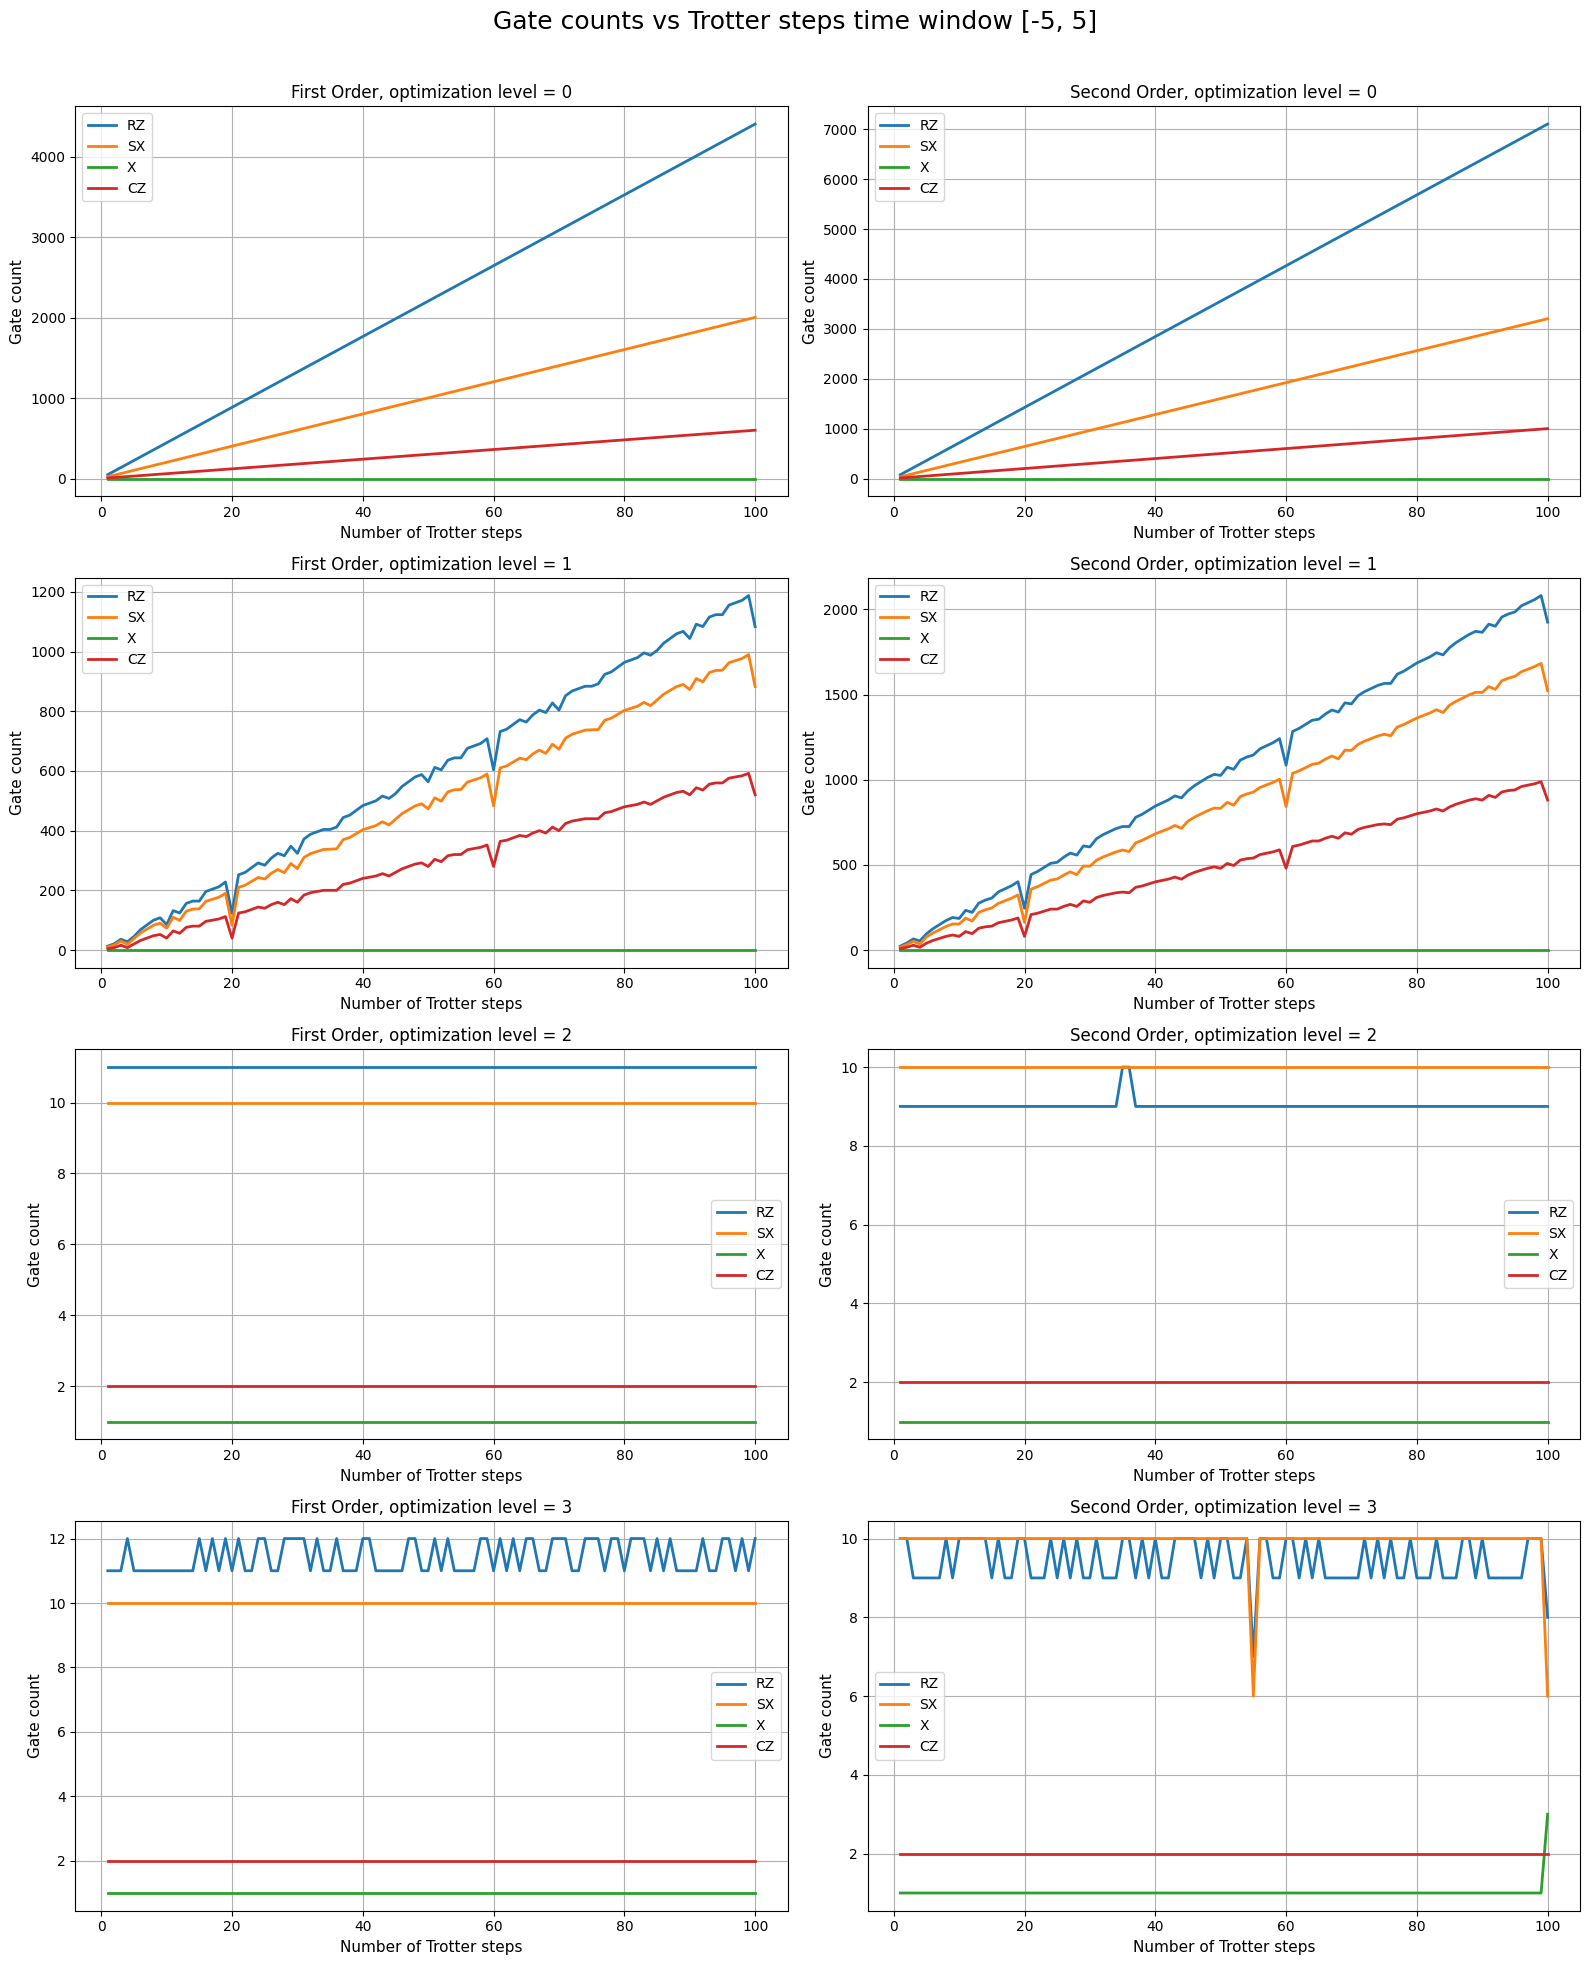

In [59]:
max_num_trotter_steps = 100
array_num_trotter_steps = np.arange(1, max_num_trotter_steps + 1)

optimization_levels = [0, 1, 2, 3]
orders = ["First", "Second"]
gates_to_track = ["rz", "sx", "x", "cz"]

gate_counts = {
    order: {
        optimization_level: {gate: [] for gate in gates_to_track}
        for optimization_level in optimization_levels
    }
    for order in orders
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=True)
display_handle = display(fig, display_id=True)

for num_trotter_steps in array_num_trotter_steps:

    for ax in axes.flatten():
        ax.clear()

    for order in orders:
        U = FS.evolution_operator(t_f=5, t_0=-5, num_Trotter_steps=num_trotter_steps, Polarization="Circular", Order_formula=order)

        qc = QuantumCircuit(2, 1)
        qc.append(FS.SWAP_test(coeff=[1, 0], U=U), [0, 1], [0])

        for optimization_level in optimization_levels:
            tqc = transpile(qc, backend=backend, optimization_level=optimization_level)
            dict_gates = tqc.count_ops()

            for gate in gates_to_track:
                gate_counts[order][optimization_level][gate].append(dict_gates.get(gate, 0))

    for row, optimization_level in enumerate(optimization_levels):
        for col, order in enumerate(orders):
            ax = axes[row, col]

            for gate in gates_to_track:
                ax.plot(array_num_trotter_steps[:len(gate_counts[order][optimization_level][gate])], gate_counts[order][optimization_level][gate], label=gate.upper(), linewidth=2)

            ax.set_title(f"{order} Order, optimization level = {optimization_level}", fontsize=12)
            ax.set_ylabel("Gate count", fontsize=11)
            ax.set_xlabel("Number of Trotter steps", fontsize=11)

            ax.tick_params(axis="x", labelbottom=True)
            ax.set_xticks(np.arange(0, max_num_trotter_steps + 1, 20))

            ax.grid(True)
            ax.legend()

    fig.suptitle("Gate counts vs Trotter steps time window [-5, 5]", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    clear_output(wait=True)
    display(fig)

plt.close(fig)

### 2.3.2 Relative MAE Error 

In [ ]:
T = 1; h1 = 1; h2=np.sqrt(2)
FS_noisy = Floquet_Simulation(T=T, parameters=[h1, h2], backend=backend, noisy=True)
noise_model = NoiseModel.from_backend(backend)
noisy_simulator = AerSimulator(noise_model=noise_model)

def get_MAE_error(t, Order_formula, num_Trotter_steps, shots=10 ** 6):
    U = FS_noisy.evolution_operator(t_f=t, t_0=0, Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, Polarization="Circular")
    qc = FS_noisy.SWAP_test(coeff=[1, 0], U=U)
    qc = transpile(qc, backend=backend, optimization_level=2)
    job = noisy_simulator.run(qc, shots=shots)
    Prob = job.result().get_counts().get('0', 0) / shots
    P_analytical = (1 + np.cos(t * FS_noisless.quasi_energy_circular())) / 2
    return abs(Prob - P_analytical) / P_analytical

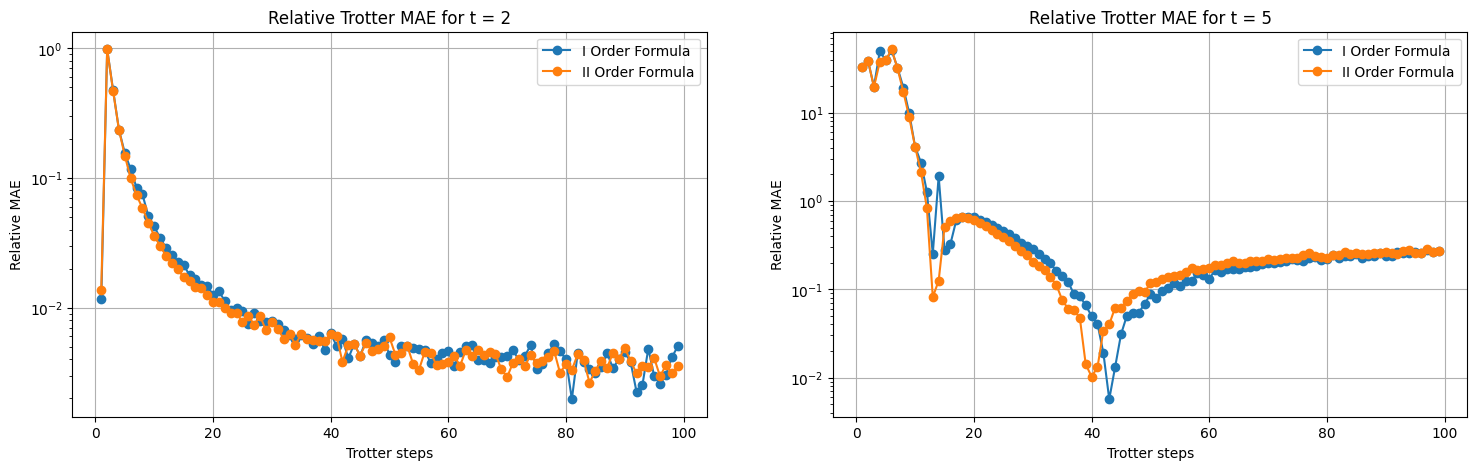

In [77]:
# Error studied in range [delta_num_Trotter_steps, Max_num_Trotter_steps] with increments of delta_num_Trotter_steps
Max_num_Trotter_steps = 100       
delta_num_Trotter_steps = 1

array_num_Trotter_steps = np.arange(delta_num_Trotter_steps, Max_num_Trotter_steps, delta_num_Trotter_steps)
t_2_MAE_error_list = [[], []]
t_5_MAE_error_list = [[], []]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
for i, num_Trotter_steps in enumerate(array_num_Trotter_steps):
    t_2_MAE_error_list[0].append(get_MAE_error(t=2, Order_formula="First", num_Trotter_steps=num_Trotter_steps))
    t_2_MAE_error_list[1].append(get_MAE_error(t=2, Order_formula="Second", num_Trotter_steps=num_Trotter_steps))
    t_5_MAE_error_list[0].append(get_MAE_error(t=5, Order_formula="First", num_Trotter_steps=num_Trotter_steps))
    t_5_MAE_error_list[1].append(get_MAE_error(t=5, Order_formula="Second", num_Trotter_steps=num_Trotter_steps))

    ax1.clear()
    ax2.clear()

    ax1.set_title(f"Relative Trotter MAE for t = 2")
    ax1.plot(array_num_Trotter_steps[:i + 1], t_2_MAE_error_list[0], '-o', label='I Order Formula')
    ax1.plot(array_num_Trotter_steps[:i + 1], t_2_MAE_error_list[1], '-o', label='II Order Formula')
    ax1.set_yscale('log')
    ax1.set_xlabel("Trotter steps")
    ax1.set_ylabel("Relative MAE")
    ax1.grid(True)
    ax1.legend()

    ax2.set_title(f"Relative Trotter MAE for t = 5")
    ax2.plot(array_num_Trotter_steps[:i + 1], t_5_MAE_error_list[0], '-o', label='I Order Formula')
    ax2.plot(array_num_Trotter_steps[:i + 1], t_5_MAE_error_list[1], '-o', label='II Order Formula')
    ax2.set_yscale('log')
    ax2.set_xlabel("Trotter steps")
    ax2.set_ylabel("Relative MAE")
    ax2.grid(True)
    ax2.legend()

    clear_output(wait=True)
    display(fig)

plt.close(fig)

The relative MAE for t = 2 converges below 0.01 when Trotter steps are increased.

While MAE for t = 5 reaches its minimum around 40 gates and then increases with the number of Trotter steps.

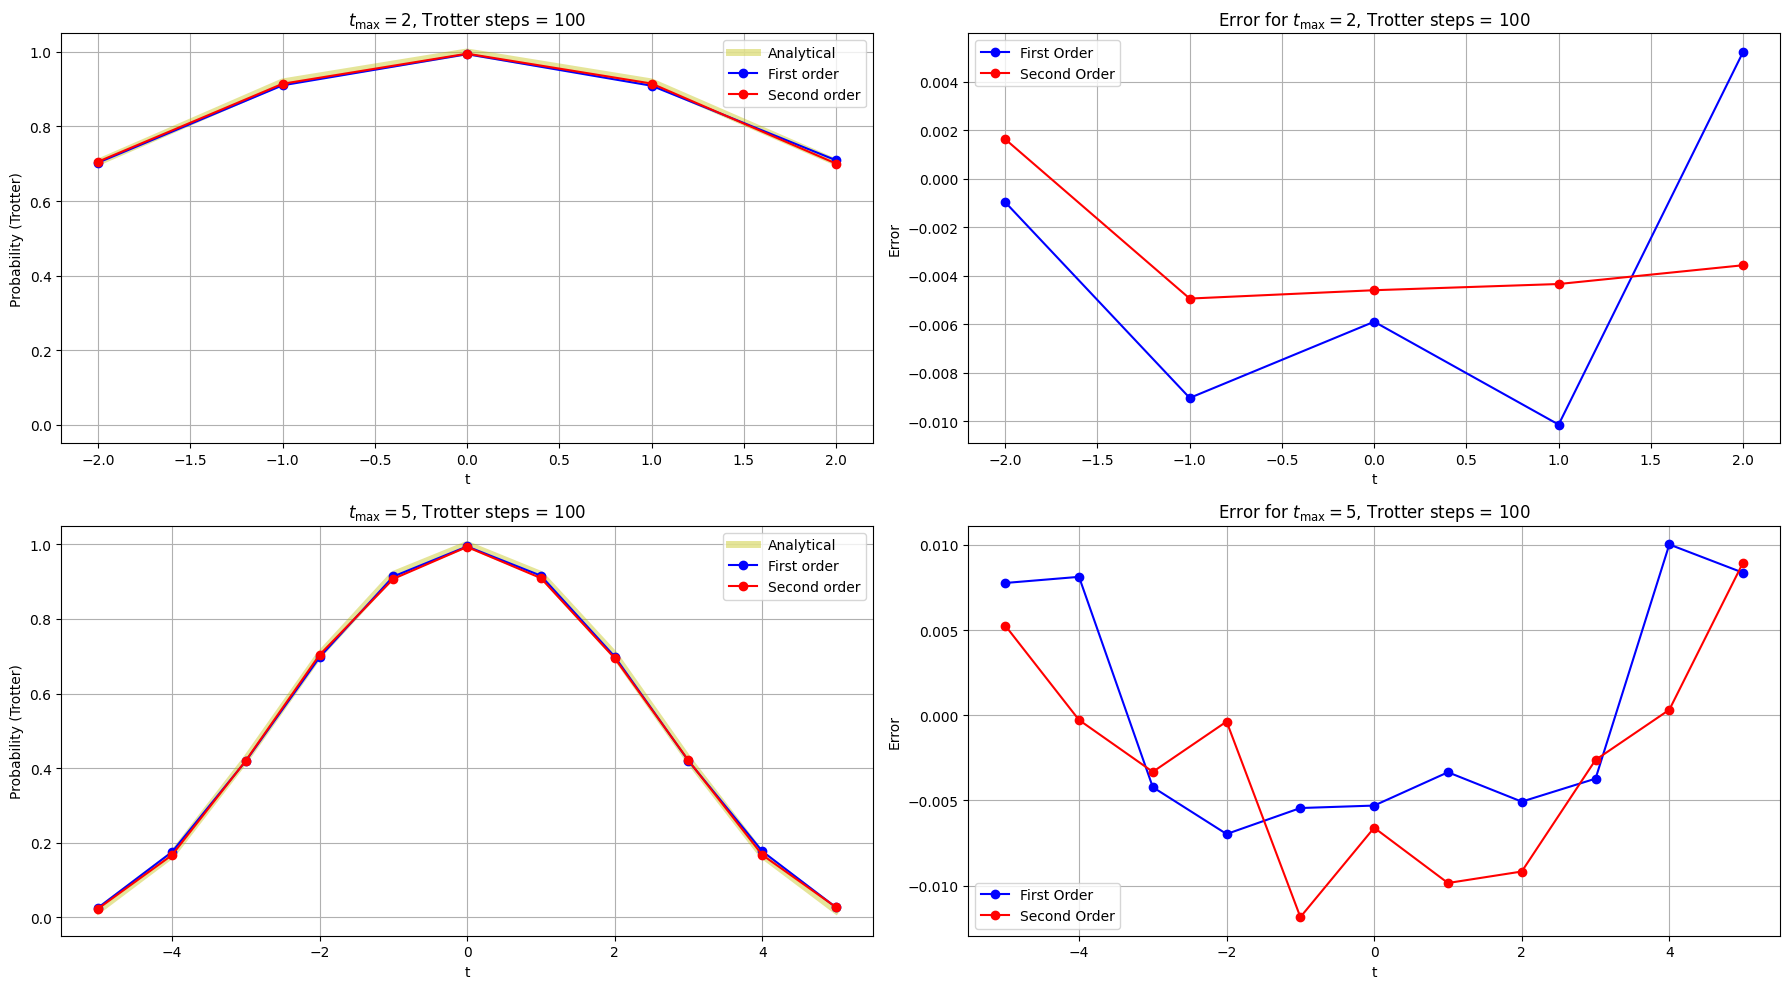

In [71]:
# Live plot :Probability distribution in function of time for different number of Trotter steps, in range [delta_num_Trotter_steps, Max_num_Trotter_steps]
# with increments of delta_num_Trotter_steps

FS_noisy = Floquet_Simulation(T=T, parameters=[h1, h2], backend=backend, noisy=True)
epsilon = FS_noisy.quasi_energy_circular()

Max_num_Trotter_steps = 101
delta_num_Trotter_steps = 1

array_num_Trotter_steps = np.arange(
    delta_num_Trotter_steps,
    Max_num_Trotter_steps,
    delta_num_Trotter_steps
)

t_max_values = [2, 5]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
display_handle = display(fig, display_id=True)

for num_Trotter_steps in array_num_Trotter_steps:
    for ax in axes.flatten():
        ax.clear()

    for row, t_max in enumerate(t_max_values):

        fname_first = f"Files/QuantumSimulation_noisy_Circular_Polarization_T={T}_Order=First_t_MAX={t_max}_Trotter_steps={num_Trotter_steps}.txt"
        if not os.path.exists(fname_first):
            FS_noisy.get_distribution0(Order_formula="First", num_Trotter_steps=num_Trotter_steps, num_points=2 * int(t_max / T), optimization_level=2)
        t_first, P_first = np.loadtxt(fname_first, unpack=True)

        fname_second = f"Files/QuantumSimulation_noisy_Circular_Polarization_T={T}_Order=Second_t_MAX={t_max}_Trotter_steps={num_Trotter_steps}.txt"
        if not os.path.exists(fname_second):
            FS_noisy.get_distribution0(Order_formula="Second", num_Trotter_steps=num_Trotter_steps, num_points=2 * int(t_max / T), optimization_level=2)
        t_second, P_second = np.loadtxt(fname_second, unpack=True)

        P_analytical = (1 + np.cos(epsilon * t_first)) / 2
        error_first = P_first - P_analytical
        error_second = P_second - P_analytical

        # probability distributions
        ax_prob = axes[row, 0]
        ax_prob.plot(t_first, P_analytical, color='y', alpha=0.4, linewidth=5, label="Analytical")
        ax_prob.plot(t_first, P_first, 'bo-', label="First order")
        ax_prob.plot(t_second, P_second, 'ro-', label="Second order")

        ax_prob.set_xlabel("t")
        ax_prob.set_ylabel("Probability (Trotter)")
        ax_prob.set_title(
            rf"$t_{{\max}}={t_max}$, Trotter steps = {num_Trotter_steps}"
        )
        ax_prob.set_ylim(-0.05, 1.05)
        ax_prob.grid(True)
        ax_prob.legend()

        # errors
        ax_err = axes[row, 1]
        ax_err.plot(t_first, error_first, 'bo-', label="First Order")
        ax_err.plot(t_second, error_second, 'ro-', label="Second Order")

        ax_err.set_xlabel("t")
        ax_err.set_ylabel("Error")
        ax_err.set_title(
            rf"Error for $t_{{\max}}={t_max}$, Trotter steps = {num_Trotter_steps}"
        )
        ax_err.grid(True)
        ax_err.legend()

    fig.tight_layout()
    clear_output(wait=True)
    plt.pause(0.2)
    display(fig)

plt.close(fig)

### 2.3.3 Study the Reconstruction error DFT and ANM with Trotter Error and Quantum noise

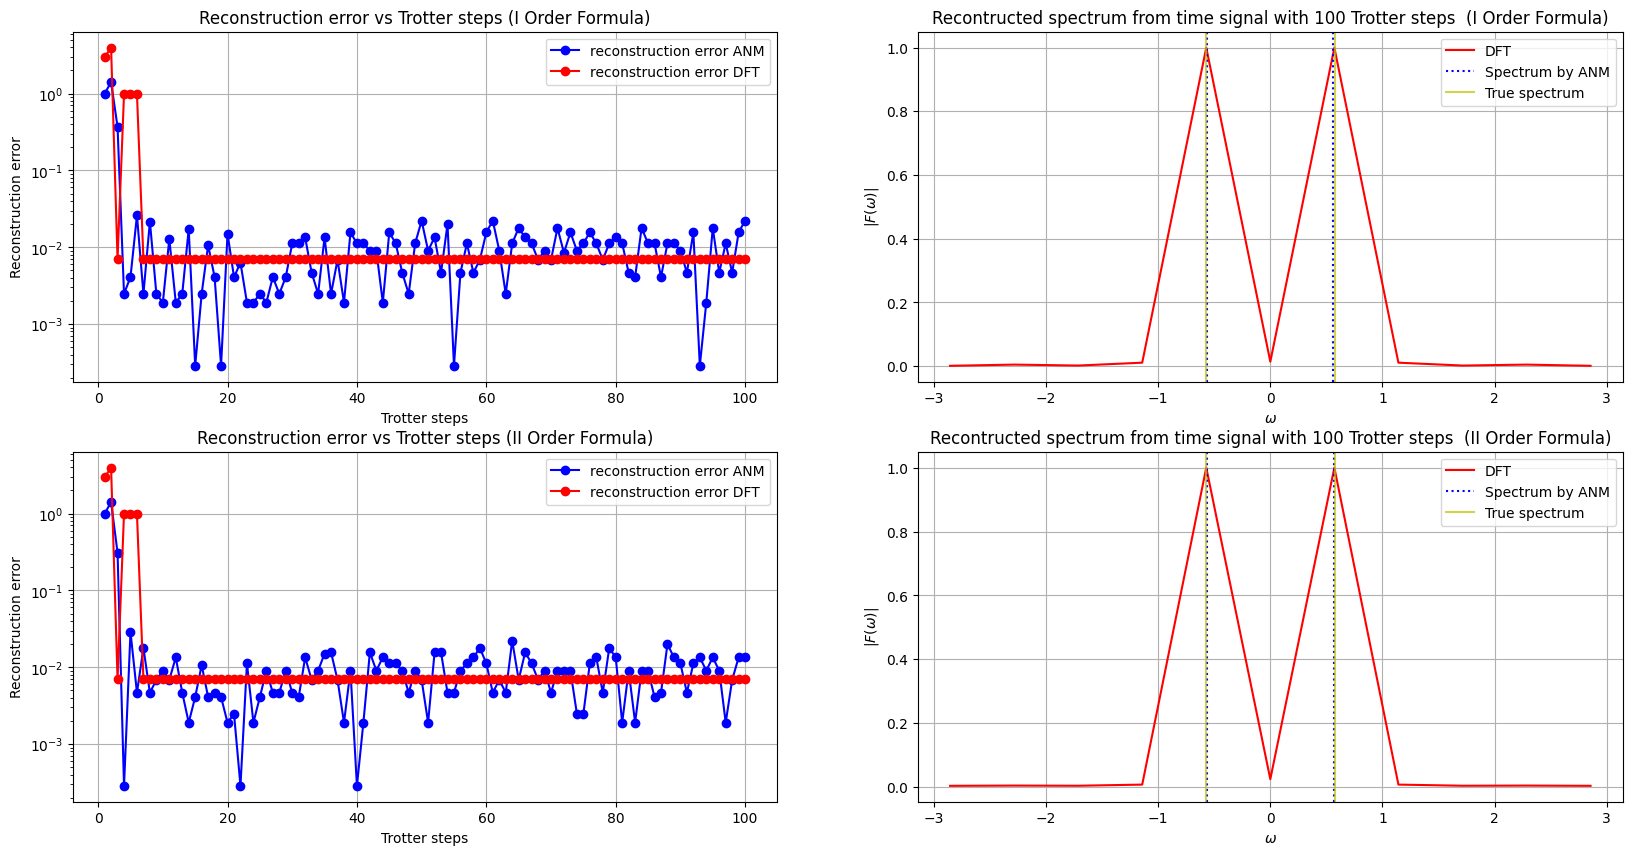

In [63]:
# Live plot: On the left Reconstruction error studied vs Trotter steps in range [delta_num_Trotter_steps, Max_num_Trotter_steps] with increments of delta_num_Trotter_steps
# On the right spectrum reconstructed with DFT and ANM using signal obtained with Trotter steps in range [delta_num_Trotter_steps, Max_num_Trotter_steps]

Max_num_Trotter_steps = 101       
delta_num_Trotter_steps = 1


array_num_Trotter_steps = np.arange(delta_num_Trotter_steps, Max_num_Trotter_steps, delta_num_Trotter_steps)
num_points_t_2 = 5
num_points_t_5 = 11
error_list_DFT_Trotter = [[], []]
error_list_ANM_Trotter = [[], []]

FS_noisy = Floquet_Simulation(T=T, parameters=[h1, h2], backend=backend, noisy=True)
epsilon = FS_noisy.quasi_energy_circular()


fig, axes = plt.subplots(2, 2, figsize=(20, 10))
for i, num_Trotter_steps in enumerate(array_num_Trotter_steps):
    [ax.clear() for ax in axes.flatten()]
    for j, Order_formula in enumerate(["First", "Second"]):
        fname_t_2 = f"Files/QuantumSimulation_noisy_Circular_Polarization_T={T}_Order={Order_formula}_t_MAX=2_Trotter_steps={num_Trotter_steps}.txt"
        fname_t_5 = f"Files/QuantumSimulation_noisy_Circular_Polarization_T={T}_Order={Order_formula}_t_MAX=5_Trotter_steps={num_Trotter_steps}.txt"
        if not os.path.exists(fname_t_2):
            FS_noisy.get_distribution0(Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, num_points=num_points_t_2, optimization_level=2)
        time_t_2, P_t_2 = np.loadtxt(fname_t_2, unpack=True)
        if not os.path.exists(fname_t_5):
            FS_noisy.get_distribution0(Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, num_points=num_points_t_5, optimization_level=2)
        time_t_5, P_t_5 = np.loadtxt(fname_t_5, unpack=True)

        DFT, ANM = Fourier_Transform(time_t_5, P_t_5 - 1/2), Atomic_Norm_Minimization(time_t_2, P_t_2 - 1/2)
        lam = max(4 * 2.25 / (num_Trotter_steps ** 2), 0.02)   #0.025
        epsilon_ANM  = np.abs(ANM.get_spectrum(-np.pi, np.pi, lam=lam, plot=False, threshold=0.05, w_exp=[epsilon], num_nu=5000)[0])
        error_list_ANM_Trotter[j].append(np.abs(epsilon - epsilon_ANM) / epsilon)
        result_DTF = DFT.get_DFT(plot=False)
        epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
        error_list_DFT_Trotter[j].append(np.abs(epsilon - epsilon_DFT) / epsilon)

 

        ax1 = axes[:,0]
        ax1[j].plot(array_num_Trotter_steps[:i + 1], error_list_ANM_Trotter[j], 'bo-', label="reconstruction error ANM")
        ax1[j].plot(array_num_Trotter_steps[:i + 1], error_list_DFT_Trotter[j], 'ro-', label="reconstruction error DFT")
        ax1[j].set_yscale('log')
        ax1[j].set_xlabel("Trotter steps")
        ax1[j].set_ylabel("Reconstruction error")
        ax1[j].set_title(f"Reconstruction error vs Trotter steps ({'I' * (j + 1)} Order Formula)")
        ax1[j].legend()
        ax1[j].grid(True)

        ax2 = axes[:,1]
        ax2[j].plot(result_DTF[0], result_DTF[1], 'r', label="DFT")
        ax2[j].set_xlabel(r'$\omega$')
        ax2[j].set_ylabel(r'$|F(\omega)|$')
        ax2[j].set_title(f"Recontructed spectrum from time signal with {num_Trotter_steps} Trotter steps  ({'I' * (j + 1)} Order Formula)")
        ax2[j].axvline(x=epsilon_ANM, color = 'b', ls = ":", label="Spectrum by ANM")
        ax2[j].axvline(x=-epsilon_ANM, color = 'b', ls = ":")
        ax2[j].axvline(x=epsilon, color = 'y', ls = "-", alpha=0.7, label="True spectrum")
        ax2[j].axvline(x=-epsilon, color = 'y', ls = "-", alpha=0.7)
        ax2[j].grid(True)
        ax2[j].legend()

    clear_output(wait=True)
    plt.pause(0.5)
    display(fig)
    [ax.clear() for ax in axes.flatten()]

plt.close(fig)

For this Hamiltonian in presence of quantum noise we can recover the quasienergies with ANM with higher accuracy than DFT.

In fact the DFT error converges around 0.007, while if we use Second Order Formula and 4 Trotter steps we can go below a reconstruction error of 0.001.
